<a href="https://colab.research.google.com/github/alejitovm97-byte/Alejo-Varelas-projects/blob/main/01_QMJ_analysis_V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# NOTEBOOK 01 — Factor Analysis (Quality + Value + Momentum)
# Based on:
#   - Asness, Frazzini & Pedersen (2017) "Quality Minus Junk"
#   - Asness, Moskowitz & Pedersen (2013) "Value and Momentum Everywhere"
# ============================================================

# --- Core ---
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, ttest_1samp

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Settings ---
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries loaded")

✓ Libraries loaded


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/TFM/Datos/'

import os
os.makedirs('/content/drive/MyDrive/TFM/outputs', exist_ok=True)
archivos = os.listdir(BASE)
print(f"✓ Drive mounted — {len(archivos)} files found")
for f in sorted(archivos):
    print(f"  {f}")

Mounted at /content/drive
✓ Drive mounted — 11 files found
  daily_historicals.xlsx
  daily_historicals_v2.xlsx
  daily_prices_refinitiv_all.csv
  daily_sp500.xlsx
  evol_historicals.xlsx
  evol_sp500.xlsx
  fundamentals_historicals.xlsx
  fundamentals_sp500.xlsx
  price_close_d_sp500.xlsx
  price_close_m_historicals.xlsx
  price_close_m_sp500.xlsx


In [ ]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def load_refinitiv(path, verbose=True):
    """
    Load a Refinitiv Excel export and return a clean long-format DataFrame.
    Handles FY, FQ, and CM period labels.
    """
    df_raw = pd.read_excel(path, header=None)
    if verbose:
        print(f"  Raw shape: {df_raw.shape}")

    row_headers = df_raw.iloc[0]
    row_periods = df_raw.iloc[1]

    # Normalize period labels: FY0 → FY-0, FQ0 → FQ-0, CM0 → CM-0
    for col_idx in range(df_raw.shape[1]):
        val = row_periods[col_idx]
        if pd.notna(val) and isinstance(val, str):
            if val in ('FY0', 'FQ0', 'CM0'):
                df_raw.iloc[1, col_idx] = val.replace('0', '-0')
    row_periods = df_raw.iloc[1]

    fixed_cols = []
    var_blocks = []
    current_var = None
    current_start = None

    for col_idx in range(df_raw.shape[1]):
        header_val = row_headers[col_idx]
        period_val = row_periods[col_idx]

        if pd.notna(header_val):
            if pd.isna(period_val):
                if current_var is not None:
                    var_blocks.append((current_var, current_start, col_idx - 1))
                    current_var = None
                fixed_cols.append((col_idx, header_val.split('\n')[0].strip()))
            else:
                if current_var is not None:
                    var_blocks.append((current_var, current_start, col_idx - 1))
                current_var = header_val.split('\n')[0].strip()
                current_start = col_idx

    if current_var is not None:
        var_blocks.append((current_var, current_start, df_raw.shape[1] - 1))

    df_data = df_raw.iloc[3:].reset_index(drop=True)

    fixed_df = pd.DataFrame()
    for col_idx, col_name in fixed_cols:
        fixed_df[col_name] = df_data[col_idx]

    first_fixed = fixed_df.columns[0]
    fixed_df = fixed_df.rename(columns={first_fixed: 'ric'})
    if len(fixed_df.columns) > 1:
        fixed_df = fixed_df.rename(columns={fixed_df.columns[1]: 'company_name'})

    results = {}
    for var_name, start_col, end_col in var_blocks:
        period_labels = [row_periods[c] for c in range(start_col, end_col + 1)]
        values_wide = df_data[list(range(start_col, end_col + 1))]
        values_wide.columns = period_labels

        melted = pd.concat([fixed_df.reset_index(drop=True), values_wide], axis=1)
        id_cols = list(fixed_df.columns)
        melted = melted.melt(id_vars=id_cols, var_name='period_label', value_name='value')
        melted['value'] = pd.to_numeric(melted['value'], errors='coerce')
        melted = melted.dropna(subset=['ric'])
        results[var_name] = melted

    if verbose:
        print(f"  Fixed columns: {list(fixed_df.columns)}")
        print(f"  Variable blocks: {len(var_blocks)}")
        for var_name, start, end in var_blocks:
            print(f"    '{var_name}' → {end - start + 1} periods")

    return results


def rank_zscore(series):
    """Cross-sectional rank z-score (Asness et al. 2017, Eq. 2)."""
    r = series.rank(method='average', na_option='keep')
    return (r - r.mean()) / r.std()


def rank_zscore_by_sector(df, col, sector_col='sector'):
    """Apply rank_zscore within each sector."""
    return df.groupby(sector_col)[col].transform(rank_zscore)


def delta_5y(df, numerator_col, denominator_col, group_col='ric'):
    """
    Five-year growth (QMJ Appendix A1):
    Δ = (numerator_t - numerator_{t-5}) / denominator_{t-5}
    """
    def _calc(g):
        num_now = g[numerator_col].values
        num_lag = g[numerator_col].shift(5).values
        den_lag = g[denominator_col].shift(5).values
        with np.errstate(divide='ignore', invalid='ignore'):
            result = (num_now - num_lag) / np.where(den_lag == 0, np.nan, den_lag)
        return pd.Series(result, index=g.index)
    return df.groupby(group_col, group_keys=False).apply(_calc)


print("✓ Helper functions defined")

✓ Helper functions defined


In [ ]:
# ============================================================
# SECCIÓN 2 — CARGA DE DATOS
# ============================================================

# 2.1 — Load all files (3 pairs: fundamentals, evol, monthly prices)

file_pairs = {
    'fundamentals': ('fundamentals_sp500.xlsx', 'fundamentals_historicals.xlsx'),
    'evol':         ('evol_sp500.xlsx', 'evol_historicals.xlsx'),
}

raw_data = {}

for name, (sp500_file, hist_file) in file_pairs.items():
    print(f"\n{'='*50}")
    print(f"Loading: {name}")

    print(f"  → SP500: {sp500_file}")
    sp500 = load_refinitiv(BASE + sp500_file)

    print(f"  → Historical: {hist_file}")
    hist = load_refinitiv(BASE + hist_file)

    combined = {}
    all_vars = set(list(sp500.keys()) + list(hist.keys()))

    for var in all_vars:
        parts = []
        if var in sp500:
            parts.append(sp500[var])
        if var in hist:
            parts.append(hist[var])

        df_combined = pd.concat(parts, ignore_index=True)
        df_combined = df_combined.drop_duplicates(subset=['ric', 'period_label'], keep='first')
        combined[var] = df_combined

    raw_data[name] = combined
    print(f"  ✓ Variables: {list(combined.keys())}")
    for var, df in combined.items():
        n_rics = df['ric'].nunique()
        print(f"    '{var}': {df.shape[0]} rows, {n_rics} unique RICs")

# Monthly prices loaded separately (uses CM labels)
print(f"\n{'='*50}")
print("Loading monthly calendar prices...")
monthly_sp500 = load_refinitiv(BASE + 'price_close_m_sp500.xlsx')
monthly_hist  = load_refinitiv(BASE + 'price_close_m_historicals.xlsx')

sp500_key = [k for k in monthly_sp500.keys() if 'price' in k.lower() or 'close' in k.lower()][0]
hist_key  = [k for k in monthly_hist.keys() if 'price' in k.lower() or 'close' in k.lower()][0]
print(f"  SP500 key: '{sp500_key}', Historical key: '{hist_key}'")

df_monthly = pd.concat([
    monthly_sp500[sp500_key],
    monthly_hist[hist_key]
], ignore_index=True)
df_monthly = df_monthly.drop_duplicates(subset=['ric', 'period_label'], keep='first')
df_monthly = df_monthly.rename(columns={'value': 'price_monthly'})
df_monthly['cm_num'] = df_monthly['period_label'].str.extract(r'CM-(\d+)').astype(float)
df_monthly = df_monthly.sort_values(['ric', 'cm_num'], ascending=[True, False])

print(f"\n=== Monthly Prices ===")
print(f"Shape: {df_monthly.shape}")
print(f"Unique RICs: {df_monthly['ric'].nunique()}")
print(f"Non-null prices: {df_monthly['price_monthly'].notna().sum()} ({df_monthly['price_monthly'].notna().mean()*100:.1f}%)")

print(f"\n{'='*50}")
print(f"✓ All files loaded")
print(f"  Fundamentals: {len(raw_data['fundamentals'])} variables")
print(f"  Evol: {len(raw_data['evol'])} variables")
print(f"  Monthly prices: {df_monthly.shape}")


Loading: fundamentals
  → SP500: fundamentals_sp500.xlsx
  Raw shape: (505, 571)
  Fixed columns: ['ric', 'company_name', 'Ticker Symbol', 'GICS Sector Name']
  Variable blocks: 27
    'Market Capitalization' → 21 periods
    'Total Assets' → 21 periods
    'Total Liabilities' → 21 periods
    'Total Current Assets' → 21 periods
    'Total Current Liabilities' → 21 periods
    'Total Debt - Actual' → 21 periods
    'Revenue from Business Activities - Total' → 21 periods
    'Gross Profit Margin - Actual' → 21 periods
    'EBIT Margin - %' → 21 periods
    'Net Income - Actual' → 21 periods
    'Interest Expense' → 21 periods
    'Net Cash Flow from Operating Activities' → 21 periods
    'Capital Expenditures - Total' → 21 periods
    'Common Shares - Outstanding - Total' → 21 periods
    'Period End Date' → 21 periods
    'Beta' → 21 periods
    'Dividend Payout Ratio - %' → 21 periods
    'Dividends Paid - Cash - Total - Cash Flow' → 21 periods
    'Stock - Common - Repurchased/Retir

In [ ]:
# ============================================================
# 2.2 — Build df_master from Period End Date
# ============================================================

fund = raw_data['fundamentals']

# Extract Period End Date → fiscal_year mapping
df_dates = fund['Period End Date'].copy()
df_dates['period_end_date'] = pd.to_datetime(df_dates['value'], errors='coerce')
df_dates = df_dates[['ric', 'period_label', 'period_end_date']].dropna(subset=['period_end_date'])

# Drop FY-0 (current fiscal year, incomplete)
df_dates = df_dates[df_dates['period_label'] != 'FY-0']

df_dates['fiscal_year'] = df_dates['period_end_date'].dt.year

print("Period End Date sample:")
print(df_dates.head(10).to_string(index=False))
print(f"\nFiscal year range: {df_dates['fiscal_year'].min()} - {df_dates['fiscal_year'].max()}")
print(f"Unique RICs with dates: {df_dates['ric'].nunique()}")

date_map = df_dates[['ric', 'period_label', 'fiscal_year', 'period_end_date']].copy()
print(f"Date mapping shape: {date_map.shape}")

fy_counts = date_map.groupby('ric').size()
print(f"FY count per RIC: min={fy_counts.min()}, median={fy_counts.median():.0f}, max={fy_counts.max()}")
print(f"\nFiscal year distribution:")
print(date_map.groupby('fiscal_year')['ric'].nunique().to_string())

Period End Date sample:
    ric period_label period_end_date  fiscal_year
  AFL.N        FY-20      2005-12-31         2005
  AES.N        FY-20      2005-12-31         2005
  ABT.N        FY-20      2005-12-31         2005
ADBE.OQ        FY-20      2005-12-02         2005
 AMD.OQ        FY-20      2005-12-25         2005
  APD.N        FY-20      2005-09-30         2005
  ALB.N        FY-20      2005-12-31         2005
 HON.OQ        FY-20      2005-12-31         2005
  ALL.N        FY-20      2005-12-31         2005
  HWM.N        FY-20      2005-12-31         2005

Fiscal year range: 1989 - 2026
Unique RICs with dates: 743
Date mapping shape: (14136, 4)
FY count per RIC: min=3, median=20, max=20

Fiscal year distribution:
fiscal_year
1989      5
1990     11
1991     18
1992     20
1993     25
1994     41
1995     52
1996     62
1997     71
1998     86
1999     92
2000     98
2001    108
2002    116
2003    124
2004    139
2005    616
2006    669
2007    681
2008    676
2009    676
2

In [ ]:
# ============================================================
# 2.3 — Merge all fundamental variables onto date_map
# ============================================================

fund = raw_data['fundamentals']

# Variable name mapping
fund_var_map = {
    'Market Capitalization':          'market_cap',
    'Total Assets':                   'total_assets',
    'Total Liabilities':              'total_liabilities',
    'Total Current Assets':           'current_assets',
    'Total Current Liabilities':      'current_liabilities',
    'Total Debt - Actual':            'total_debt',
    'Revenue from Business Activities - Total': 'revenue',
    'Gross Profit Margin - Actual':   'gross_margin',
    'EBIT Margin - %':                'ebit_margin',
    'Net Income - Actual':            'net_income',
    'Interest Expense':               'interest_expense',
    'Net Cash Flow from Operating Activities': 'op_cash_flow',
    'Capital Expenditures - Total':   'capex',
    'Common Shares - Outstanding - Total': 'shares_outstanding',
    'Common Equity - Total':          'common_equity',
    'Beta':                           'beta',
    'Dividend Payout Ratio - %':      'payout_ratio',
    'Dividends Paid - Cash - Total - Cash Flow': 'dividends',
    'Stock - Common - Repurchased/Retired - Cash Flow': 'buybacks',
    'Cash & Short Term Investments':  'cash_equiv',
    'Short-Term Debt & Current Portion of Long-Term Debt': 'st_debt',
    'Income Taxes - Payable - Long-Term & Short-Term': 'taxes_payable',
    'Depreciation & Amortization - Actual': 'depreciation',
    'Retained Earnings - Total':      'retained_earnings',
    'Pre-Tax Profit - Actual':        'pretax_income',
    'Price Close':                    'price_close',
}

# Start with date_map
df_master = date_map.copy()

# Add sector
sector_df = fund['Market Capitalization'][['ric', 'GICS Sector Name']].drop_duplicates(subset='ric')
sector_df = sector_df.rename(columns={'GICS Sector Name': 'sector'})
df_master = df_master.merge(sector_df, on='ric', how='left')

# Merge each variable (skip FY-0 rows)
for ref_name, clean_name in fund_var_map.items():
    var_df = fund[ref_name][['ric', 'period_label', 'value']].copy()
    var_df = var_df[var_df['period_label'] != 'FY-0']
    var_df = var_df.rename(columns={'value': clean_name})
    df_master = df_master.merge(var_df, on=['ric', 'period_label'], how='left')

print(f"df_master shape: {df_master.shape}")
print(f"Columns ({len(df_master.columns)}): {list(df_master.columns)}")

print(f"\nNull % (top 15):")
null_pct = (df_master.isnull().sum() / len(df_master) * 100).sort_values(ascending=False)
for col, pct in null_pct.head(15).items():
    print(f"  {col:30s} {pct:6.1f}%")

print(f"\nSample (2024):")
sample = df_master[df_master['fiscal_year'] == 2024].head(3)
print(sample[['ric', 'fiscal_year', 'sector', 'market_cap', 'total_assets',
              'revenue', 'net_income', 'common_equity']].to_string(index=False))

df_master shape: (14136, 31)
Columns (31): ['ric', 'period_label', 'fiscal_year', 'period_end_date', 'sector', 'market_cap', 'total_assets', 'total_liabilities', 'current_assets', 'current_liabilities', 'total_debt', 'revenue', 'gross_margin', 'ebit_margin', 'net_income', 'interest_expense', 'op_cash_flow', 'capex', 'shares_outstanding', 'common_equity', 'beta', 'payout_ratio', 'dividends', 'buybacks', 'cash_equiv', 'st_debt', 'taxes_payable', 'depreciation', 'retained_earnings', 'pretax_income', 'price_close']

Null % (top 15):
  total_debt                       67.2%
  beta                             58.3%
  depreciation                     50.7%
  taxes_payable                    46.8%
  gross_margin                     36.9%
  dividends                        26.3%
  buybacks                         22.1%
  sector                           16.0%
  pretax_income                    15.6%
  payout_ratio                     12.4%
  current_assets                   11.8%
  current_liab

In [ ]:
# ============================================================
# 2.4 — Prepare quarterly ROE for EVOL
# ============================================================

df_roe_quarterly = raw_data['evol']['Return On Equity - Actual'][['ric', 'period_label', 'value']].copy()
df_roe_quarterly = df_roe_quarterly.rename(columns={'value': 'roe_quarterly'})
df_roe_quarterly['fq_num'] = df_roe_quarterly['period_label'].str.extract(r'FQ-(\d+)').astype(float)
df_roe_quarterly = df_roe_quarterly.sort_values(['ric', 'fq_num'], ascending=[True, False])

print("=== Quarterly ROE (for EVOL) ===")
print(f"Shape: {df_roe_quarterly.shape}")
print(f"Unique RICs: {df_roe_quarterly['ric'].nunique()}")
print(f"Non-null ROE: {df_roe_quarterly['roe_quarterly'].notna().sum()} ({df_roe_quarterly['roe_quarterly'].notna().mean()*100:.1f}%)")

roe_counts = df_roe_quarterly.groupby('ric')['roe_quarterly'].apply(lambda x: x.notna().sum())
print(f"\nQuarters per RIC: min={roe_counts.min()}, median={roe_counts.median():.0f}, max={roe_counts.max()}")
print(f"RICs with >= 12 quarters: {(roe_counts >= 12).sum()}")

print(f"\n=== Monthly Prices (already loaded) ===")
print(f"Shape: {df_monthly.shape}, RICs: {df_monthly['ric'].nunique()}")

print(f"\n✓ Section 2 complete")
print(f"  df_master:         {df_master.shape}")
print(f"  df_roe_quarterly:  {df_roe_quarterly.shape}")
print(f"  df_monthly:        {df_monthly.shape}")

=== Quarterly ROE (for EVOL) ===
Shape: (45567, 4)
Unique RICs: 747
Non-null ROE: 28579 (62.7%)

Quarters per RIC: min=0, median=42, max=61
RICs with >= 12 quarters: 644

=== Monthly Prices (already loaded) ===
Shape: (179786, 5), RICs: 746

✓ Section 2 complete
  df_master:         (14136, 31)
  df_roe_quarterly:  (45567, 4)
  df_monthly:        (179786, 5)


In [ ]:
# ============================================================
# SECCIÓN 3 — LIMPIEZA (v3)
# ============================================================

print(f"Starting shape: {df_master.shape}")
print(f"Starting unique RICs: {df_master['ric'].nunique()}")

# ─────────────────────────────────────────────
# 3.1 — Universe filters
# ─────────────────────────────────────────────

# Filter 1: Market Cap >= $2B (ever)
mcap_threshold = 2e9
rics_above_mcap = df_master.loc[
    df_master['market_cap'] >= mcap_threshold, 'ric'
].unique()

n_before = df_master['ric'].nunique()
df_master = df_master[df_master['ric'].isin(rics_above_mcap)].copy()
n_after = df_master['ric'].nunique()
print(f"\nFilter 1 — Market Cap >= $2B (ever):")
print(f"  {n_before} → {n_after} RICs (dropped {n_before - n_after})")

# Filter 2: Minimum trading history >= 5 fiscal years
fy_counts = df_master.groupby('ric')['fiscal_year'].nunique()
rics_enough_history = fy_counts[fy_counts >= 5].index

n_before = df_master['ric'].nunique()
df_master = df_master[df_master['ric'].isin(rics_enough_history)].copy()
n_after = df_master['ric'].nunique()
print(f"\nFilter 2 — Trading history >= 5 fiscal years:")
print(f"  {n_before} → {n_after} RICs (dropped {n_before - n_after})")

# ─────────────────────────────────────────────
# 3.2 — Drop rows without sector (can't impute or neutralize)
# ─────────────────────────────────────────────

n_before = len(df_master)
df_master = df_master.dropna(subset=['sector']).copy()
n_after = len(df_master)
print(f"\nFilter 3 — Drop rows without sector:")
print(f"  Rows: {n_before} → {n_after} (dropped {n_before - n_after})")

# ─────────────────────────────────────────────
# 3.3 — Row-level filtering on critical variables
# ─────────────────────────────────────────────

critical_vars = ['market_cap', 'total_assets', 'net_income', 'common_equity', 'revenue']

n_before = len(df_master)
rics_before = df_master['ric'].nunique()
mask_critical = df_master[critical_vars].notna().all(axis=1)
df_master = df_master[mask_critical].copy()
n_after = len(df_master)
rics_after = df_master['ric'].nunique()
print(f"\nFilter 4 — Drop ROWS missing critical vars:")
print(f"  Rows: {n_before} → {n_after} (dropped {n_before - n_after})")
print(f"  RICs: {rics_before} → {rics_after} (lost {rics_before - rics_after})")

# Keep only RICs with >= 3 remaining years
fy_counts_2 = df_master.groupby('ric')['fiscal_year'].nunique()
rics_enough = fy_counts_2[fy_counts_2 >= 3].index
n_before = df_master['ric'].nunique()
df_master = df_master[df_master['ric'].isin(rics_enough)].copy()
n_after = df_master['ric'].nunique()
print(f"\nFilter 5 — Keep RICs with >= 3 remaining fiscal years:")
print(f"  {n_before} → {n_after} RICs (dropped {n_before - n_after})")

# ─────────────────────────────────────────────
# 3.4 — Imputation
# ─────────────────────────────────────────────

# Beta: sector-year median, then 1.0
beta_null_before = df_master['beta'].isnull().sum()
df_master['beta'] = df_master.groupby(['fiscal_year', 'sector'])['beta'].transform(
    lambda x: x.fillna(x.median())
)
df_master['beta'] = df_master['beta'].fillna(1.0)
print(f"\nBeta imputation: {beta_null_before} nulls → {df_master['beta'].isnull().sum()}")

# taxes_payable and st_debt: fill with 0 (legitimately zero)
for col in ['taxes_payable', 'st_debt']:
    df_master[col] = df_master[col].fillna(0)

# Sector-median imputation for remaining numeric vars
numeric_cols = df_master.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'fiscal_year']

imputed_count = 0
for col in numeric_cols:
    before_nulls = df_master[col].isnull().sum()
    df_master[col] = df_master.groupby(['fiscal_year', 'sector'])[col].transform(
        lambda x: x.fillna(x.median())
    )
    after_nulls = df_master[col].isnull().sum()
    imputed_count += (before_nulls - after_nulls)

print(f"\nSector-median imputation: {imputed_count} values filled")
remaining = df_master[numeric_cols].isnull().sum()
remaining_nonzero = remaining[remaining > 0]
if len(remaining_nonzero) > 0:
    print(f"Remaining nulls:")
    for col, n in remaining_nonzero.items():
        print(f"  {col:30s} {n:5d} ({n/len(df_master)*100:.1f}%)")
else:
    print("  No remaining nulls!")

# ─────────────────────────────────────────────
# 3.5 — Winsorize (cross-sectional, per year, p1-p99)
# ─────────────────────────────────────────────

vars_to_winsorize = [c for c in numeric_cols if c not in ['fiscal_year']]

def safe_winsorize(series, limits=[0.01, 0.01]):
    valid = series.dropna()
    if len(valid) < 10:
        return series
    result = series.copy()
    lower = valid.quantile(limits[0])
    upper = valid.quantile(1 - limits[1])
    result = result.clip(lower=lower, upper=upper)
    return result

for col in vars_to_winsorize:
    df_master[col] = df_master.groupby('fiscal_year')[col].transform(safe_winsorize)

print(f"\nWinsorized {len(vars_to_winsorize)} variables at p1-p99 by fiscal year")

# ─────────────────────────────────────────────
# 3.6 — Coherence validation
# ─────────────────────────────────────────────

print(f"\n{'='*50}")
print("Coherence checks:")
print(f"  total_assets <= 0: {(df_master['total_assets'] <= 0).sum()} rows")
print(f"  total_assets < 0.95 × total_liabilities: {(df_master['total_assets'] < df_master['total_liabilities'] * 0.95).sum()} rows")
print(f"  market_cap <= 0: {(df_master['market_cap'] <= 0).sum()} rows")
print(f"  common_equity < 0: {(df_master['common_equity'] < 0).sum()} rows (not an error)")

mask_incoherent = (df_master['total_assets'] <= 0) | (df_master['market_cap'] <= 0)
n_removed = mask_incoherent.sum()
df_master = df_master[~mask_incoherent].copy()
print(f"  Removed {n_removed} incoherent rows")

# Key companies
print(f"\n{'='*50}")
key_companies = ['AAPL.OQ', 'MSFT.OQ', 'GOOGL.OQ', 'AMZN.OQ', 'MA.N', 'ABBV.N']
print("Key company check:")
for ric in key_companies:
    n_years = df_master[df_master['ric'] == ric]['fiscal_year'].nunique()
    status = "✓" if n_years > 0 else "✗ MISSING"
    print(f"  {ric:<12} {status} ({n_years} fiscal years)")

# Final summary
print(f"\n{'='*50}")
print(f"✓ Section 3 complete")
print(f"  Final shape: {df_master.shape}")
print(f"  Final unique RICs: {df_master['ric'].nunique()}")
print(f"  Fiscal year range: {df_master['fiscal_year'].min()}-{df_master['fiscal_year'].max()}")
print(f"\n  RICs per fiscal year (key years):")
fy_dist = df_master.groupby('fiscal_year')['ric'].nunique()
for year in range(2005, 2026):
    if year in fy_dist.index:
        print(f"    {year}: {fy_dist[year]}")

Starting shape: (14136, 31)
Starting unique RICs: 743

Filter 1 — Market Cap >= $2B (ever):
  743 → 737 RICs (dropped 6)

Filter 2 — Trading history >= 5 fiscal years:
  737 → 736 RICs (dropped 1)

Filter 3 — Drop rows without sector:
  Rows: 14049 → 11840 (dropped 2209)

Filter 4 — Drop ROWS missing critical vars:
  Rows: 11840 → 10922 (dropped 918)
  RICs: 618 → 615 (lost 3)

Filter 5 — Keep RICs with >= 3 remaining fiscal years:
  615 → 608 RICs (dropped 7)

Beta imputation: 5362 nulls → 0

Sector-median imputation: 13833 values filled
Remaining nulls:
  current_assets                     4 (0.0%)
  current_liabilities                4 (0.0%)
  total_debt                      5618 (51.5%)
  gross_margin                     260 (2.4%)
  interest_expense                   2 (0.0%)
  payout_ratio                       5 (0.0%)
  dividends                         21 (0.2%)
  buybacks                           6 (0.1%)
  cash_equiv                         4 (0.0%)
  depreciation         

In [ ]:
# ============================================================
# SECCIÓN 4 — VARIABLES INTERMEDIAS
# ============================================================

df_master = df_master.sort_values(['ric', 'fiscal_year']).reset_index(drop=True)

# ─────────────────────────────────────────────
# 4.1 — Variables base
# ─────────────────────────────────────────────
df_master['gross_profit'] = df_master['gross_margin'] * df_master['revenue']
df_master['ebit'] = df_master['ebit_margin'] * df_master['revenue']

print("4.1 — Base variables")
print(f"  gross_profit: {df_master['gross_profit'].notna().sum()} non-null, <0: {(df_master['gross_profit'] < 0).sum()}")
print(f"  ebit:         {df_master['ebit'].notna().sum()} non-null")

# ─────────────────────────────────────────────
# 4.2 — Working Capital (definición Asness QMJ)
# WC = Current Assets − Current Liabilities − Cash + ST Debt + Taxes Payable
# Se mantiene porque es necesaria para ACCRUALS (Sloan 1996)
# ─────────────────────────────────────────────
for col in ['taxes_payable', 'st_debt']:
    df_master[col] = df_master[col].fillna(0)

df_master['working_capital'] = (
    df_master['current_assets']
    - df_master['current_liabilities']
    - df_master['cash_equiv']
    + df_master['st_debt']
    + df_master['taxes_payable']
)
df_master['delta_wc'] = df_master.groupby('ric')['working_capital'].diff()

print(f"\n4.2 — Working Capital: {df_master['working_capital'].notna().sum()} non-null")

# ─────────────────────────────────────────────
# 4.3 — CFOA (CAMBIO: flujo de caja operativo DIRECTO)
# ────────────────────────────────────────────────────────────
# DESVIACIÓN DOCUMENTADA respecto a QMJ Appendix A1:
#   El paper define CFOA = (NI + Depreciation − ΔWC − Capex) / Assets
#   (construcción accrual-based).
#   Nosotros usamos el Net Cash Flow from Operating Activities
#   reportado directamente por Refinitiv, dividido por Total Assets.
#
#   Justificación:
#   (1) Mayor cobertura de datos: op_cash_flow tiene ~5% nulls vs
#       ~40% del CFOA construido (que depende de depreciation y ΔWC).
#   (2) Ambas medidas correlacionan a ~0.61, capturando la misma señal.
#   (3) El operating cash flow reportado es una medida directa y auditada
#       de generación de caja operativa.
# ─────────────────────────────────────────────
df_master['cfoa'] = df_master['op_cash_flow'] / df_master['total_assets'].replace(0, np.nan)

print(f"\n4.3 — CFOA (directo desde op_cash_flow)")
print(f"  cfoa non-null: {df_master['cfoa'].notna().sum()}")
print(f"  cfoa median:   {df_master['cfoa'].median():.4f}")

# Comparación con la versión construida (solo informativo, no se usa)
cash_flow_construido = (
    df_master['net_income']
    + df_master['depreciation']
    - df_master['delta_wc']
    - df_master['capex'].abs()
)
cfoa_construido = cash_flow_construido / df_master['total_assets'].replace(0, np.nan)
corr_versiones = pd.concat([df_master['cfoa'], cfoa_construido], axis=1).corr().iloc[0, 1]
print(f"  cfoa construido non-null: {cfoa_construido.notna().sum()} (comparación)")
print(f"  corr(cfoa_directo, cfoa_construido) = {corr_versiones:.3f}")

# ─────────────────────────────────────────────
# 4.4 — Accruals (Sloan 1996) — SIN CAMBIOS, fiel al paper
# ACC = −(ΔWC − Depreciation) / Total Assets
# ─────────────────────────────────────────────
df_master['accruals'] = -(df_master['delta_wc'] - df_master['depreciation']) / df_master['total_assets'].replace(0, np.nan)

print(f"\n4.4 — Accruals (Sloan 1996): {df_master['accruals'].notna().sum()} non-null")

print(f"\n✓ Section 4 complete — df_master shape: {df_master.shape}")

4.1 — Base variables
  gross_profit: 10650 non-null, <0: 0
  ebit:         10910 non-null

4.2 — Working Capital: 10902 non-null

4.3 — CFOA (directo desde op_cash_flow)
  cfoa non-null: 10910
  cfoa median:   0.0956
  cfoa construido non-null: 6859 (comparación)
  corr(cfoa_directo, cfoa_construido) = 0.610

4.4 — Accruals (Sloan 1996): 6859 non-null

✓ Section 4 complete — df_master shape: (10910, 37)


In [ ]:
# ============================================================
# SECCIÓN 5 — QUALITY SCORE
# ============================================================

# 5.1 — PROFITABILITY
df_master['gpoa'] = df_master['gross_profit'] / df_master['total_assets'].replace(0, np.nan)
df_master['roe']  = df_master['net_income'] / df_master['common_equity'].replace(0, np.nan)
df_master['roa']  = df_master['net_income'] / df_master['total_assets'].replace(0, np.nan)

print("5.1 — Profitability: raw ratios")
prof_vars = ['gpoa', 'roe', 'roa', 'cfoa', 'gross_margin', 'accruals']
for v in prof_vars:
    n = df_master[v].notna().sum()
    med = df_master[v].median()
    print(f"  {v:15s}  median={med:8.4f}  non-null={n}")

for v in prof_vars:
    df_master[f'z_{v}'] = df_master.groupby('fiscal_year')[v].transform(rank_zscore)

z_prof_cols = [f'z_{v}' for v in prof_vars]
df_master['prof_sum'] = df_master[z_prof_cols].sum(axis=1, min_count=4)
df_master['profitability'] = df_master.groupby('fiscal_year')['prof_sum'].transform(rank_zscore)

print(f"\n  Profitability: non-null={df_master['profitability'].notna().sum()}, "
      f"mean={df_master['profitability'].mean():.4f}, std={df_master['profitability'].std():.4f}")

print(f"\n  Correlation matrix:")
corr_prof = df_master[z_prof_cols].corr()
corr_prof.columns = prof_vars
corr_prof.index = prof_vars
print(corr_prof.round(3).to_string())

5.1 — Profitability: raw ratios
  gpoa             median=  0.2377  non-null=10650
  roe              median=  0.1623  non-null=10910
  roa              median=  0.0631  non-null=10910
  cfoa             median=  0.0956  non-null=10910
  gross_margin     median=  0.4536  non-null=10650
  accruals         median=  0.0326  non-null=6859

  Profitability: non-null=10650, mean=0.0000, std=0.9991

  Correlation matrix:
               gpoa     roe    roa   cfoa  gross_margin  accruals
gpoa         1.0000  0.4620 0.7030 0.6540        0.1040    0.1340
roe          0.4620  1.0000 0.6560 0.4940       -0.0400   -0.0020
roa          0.7030  0.6560 1.0000 0.7890        0.0490    0.0340
cfoa         0.6540  0.4940 0.7890 1.0000        0.0470    0.3160
gross_margin 0.1040 -0.0400 0.0490 0.0470        1.0000   -0.0480
accruals     0.1340 -0.0020 0.0340 0.3160       -0.0480    1.0000


In [ ]:
# 5.2 — GROWTH (5-year changes, correct denominator)
df_master['d_gpoa'] = delta_5y(df_master, 'gross_profit', 'total_assets')
df_master['d_roe']  = delta_5y(df_master, 'net_income', 'common_equity')
df_master['d_roa']  = delta_5y(df_master, 'net_income', 'total_assets')
df_master['d_cfoa'] = delta_5y(df_master, 'op_cash_flow', 'total_assets')
df_master['d_gmar'] = delta_5y(df_master, 'gross_profit', 'revenue')

print("5.2 — Growth: 5-year changes")
growth_vars = ['d_gpoa', 'd_roe', 'd_roa', 'd_cfoa', 'd_gmar']
for v in growth_vars:
    n = df_master[v].notna().sum()
    med = df_master[v].dropna().median()
    print(f"  {v:10s}  median={med:8.4f}  non-null={n}")

for v in growth_vars:
    df_master[f'z_{v}'] = df_master.groupby('fiscal_year')[v].transform(rank_zscore)

z_growth_cols = [f'z_{v}' for v in growth_vars]
df_master['growth_sum'] = df_master[z_growth_cols].sum(axis=1, min_count=3)
df_master['growth'] = df_master.groupby('fiscal_year')['growth_sum'].transform(rank_zscore)

print(f"\n  Growth: non-null={df_master['growth'].notna().sum()}, "
      f"mean={df_master['growth'].mean():.4f}, std={df_master['growth'].std():.4f}")

print(f"\n  Growth by fiscal year:")
growth_by_year = df_master.groupby('fiscal_year')['growth'].apply(lambda x: x.notna().sum())
for year, n in growth_by_year.items():
    if n > 0:
        print(f"    {year}: {n}")

5.2 — Growth: 5-year changes
  d_gpoa      median=  0.0679  non-null=7619
  d_roe       median=  0.0713  non-null=7879
  d_roa       median=  0.0258  non-null=7879
  d_cfoa      median=  0.0368  non-null=7879
  d_gmar      median=  0.1325  non-null=7619

  Growth: non-null=7878, mean=0.0000, std=0.9988

  Growth by fiscal year:
    2006: 4
    2007: 6
    2008: 11
    2009: 17
    2010: 405
    2011: 471
    2012: 489
    2013: 493
    2014: 486
    2015: 506
    2016: 525
    2017: 531
    2018: 540
    2019: 548
    2020: 543
    2021: 561
    2022: 577
    2023: 571
    2024: 564
    2025: 30


In [ ]:
# 5.3 — SAFETY
# Safety = z(z_BAB + z_LEV + z_ALTMAN_Z + z_OHLSON_O + z_EVOL)

# BAB = -beta (low beta = safer)
df_master['bab'] = -df_master['beta']

# LEV = -total_liabilities / total_assets
df_master['lev'] = -df_master['total_liabilities'] / df_master['total_assets'].replace(0, np.nan)

# Altman Z-Score
df_master['altman_z'] = (
    1.2 * (df_master['current_assets'] - df_master['current_liabilities']) / df_master['total_assets'].replace(0, np.nan) +
    1.4 * df_master['retained_earnings'] / df_master['total_assets'].replace(0, np.nan) +
    3.3 * df_master['ebit'] / df_master['total_assets'].replace(0, np.nan) +
    0.6 * df_master['market_cap'] / df_master['total_liabilities'].replace(0, np.nan) +
    1.0 * df_master['revenue'] / df_master['total_assets'].replace(0, np.nan)
)

# Ohlson O-Score (simplified, inverted — higher = safer)
log_at = np.log(df_master['total_assets'].replace(0, np.nan))
tlta = df_master['total_liabilities'] / df_master['total_assets'].replace(0, np.nan)
wcta = (df_master['current_assets'] - df_master['current_liabilities']) / df_master['total_assets'].replace(0, np.nan)
clca = df_master['current_liabilities'] / df_master['current_assets'].replace(0, np.nan)
oeneg = (df_master['total_liabilities'] > df_master['total_assets']).astype(int)
nita = df_master['net_income'] / df_master['total_assets'].replace(0, np.nan)
futl = df_master['pretax_income'] / df_master['total_liabilities'].replace(0, np.nan)

ni_lag1 = df_master.groupby('ric')['net_income'].shift(1)
intwo = ((df_master['net_income'] < 0) & (ni_lag1 < 0)).astype(int)

ni_t = df_master['net_income']
chin = (ni_t - ni_lag1) / (ni_t.abs() + ni_lag1.abs()).replace(0, np.nan)

df_master['ohlson_o'] = -(
    -1.32 - 0.407 * log_at + 6.03 * tlta - 1.43 * wcta + 0.076 * clca
    - 1.72 * oeneg - 2.37 * nita - 1.83 * futl + 0.285 * intwo - 0.521 * chin
)

# ─────────────────────────────────────────────
# EVOL — Rolling std of quarterly ROE (corrected, no look-ahead bias)
# For each RIC × fiscal_year, uses only quarters UP TO that period_end_date
# Minimum 12 quarters required for a valid estimate
# ─────────────────────────────────────────────

# Step 1: Anchor each quarter to an approximate calendar date
# FQ-0 is the most recent quarter for each RIC
# We use each RIC's latest period_end_date as the anchor for FQ-0
latest_ped = df_master.groupby('ric')['period_end_date'].max().reset_index()
latest_ped = latest_ped.rename(columns={'period_end_date': 'latest_ped'})

df_roe_q = df_roe_quarterly.merge(latest_ped, on='ric', how='left')

# Each quarter is ~91.25 days apart
# FQ-0 ≈ latest_ped, FQ-1 ≈ latest_ped - 3 months, etc.
df_roe_q['quarter_date'] = df_roe_q['latest_ped'] - pd.to_timedelta(df_roe_q['fq_num'] * 91.25, unit='D')

# Step 2: For each RIC × fiscal_year, compute EVOL using only quarters <= period_end_date
print("  Computing rolling EVOL (no look-ahead)...")

# Pre-group quarterly data by RIC for speed
roe_by_ric = {}
for ric, group in df_roe_q.groupby('ric'):
    # Keep only non-null ROE rows, sorted by quarter_date
    valid = group.dropna(subset=['roe_quarterly', 'quarter_date'])[['quarter_date', 'roe_quarterly']].copy()
    valid = valid.sort_values('quarter_date')
    roe_by_ric[ric] = valid

min_quarters = 12
evol_values = []

for _, row in df_master[['ric', 'period_end_date']].iterrows():
    ric = row['ric']
    ped = row['period_end_date']

    if pd.isna(ped) or ric not in roe_by_ric:
        evol_values.append(np.nan)
        continue

    ric_roe = roe_by_ric[ric]

    # Only use quarters with date <= this fiscal year's period_end_date
    valid_roe = ric_roe[ric_roe['quarter_date'] <= ped]['roe_quarterly']

    if len(valid_roe) >= min_quarters:
        evol_values.append(-valid_roe.std())
    else:
        evol_values.append(np.nan)

df_master['evol'] = evol_values
print(f"  EVOL non-null: {df_master['evol'].notna().sum()}")

# ─────────────────────────────────────────────
# Safety composite score
# ─────────────────────────────────────────────

print("\n5.3 — Safety: raw components")
safety_raw = ['bab', 'lev', 'altman_z', 'ohlson_o', 'evol']
for v in safety_raw:
    n = df_master[v].notna().sum()
    med = df_master[v].dropna().median()
    print(f"  {v:12s}  median={med:8.4f}  non-null={n}")

for v in safety_raw:
    df_master[f'z_{v}'] = df_master.groupby('fiscal_year')[v].transform(rank_zscore)

z_safety_cols = [f'z_{v}' for v in safety_raw]
df_master['safety_sum'] = df_master[z_safety_cols].sum(axis=1, min_count=3)
df_master['safety'] = df_master.groupby('fiscal_year')['safety_sum'].transform(rank_zscore)

print(f"\n  Safety: non-null={df_master['safety'].notna().sum()}, "
      f"mean={df_master['safety'].mean():.4f}, std={df_master['safety'].std():.4f}")

print(f"\n  Correlation matrix:")
corr_safety = df_master[z_safety_cols].corr()
corr_safety.columns = safety_raw
corr_safety.index = safety_raw
print(corr_safety.round(3).to_string())

  Computing rolling EVOL (no look-ahead)...
  EVOL non-null: 5464

5.3 — Safety: raw components
  bab           median= -1.0000  non-null=10910
  lev           median= -0.6241  non-null=10910
  altman_z      median=  2.7362  non-null=10906
  ohlson_o      median=  7.5574  non-null=10298
  evol          median= -0.0681  non-null=5464

  Safety: non-null=10865, mean=-0.0000, std=0.9989

  Correlation matrix:
             bab     lev  altman_z  ohlson_o    evol
bab       1.0000 -0.0440    0.0260   -0.0360  0.0750
lev      -0.0440  1.0000    0.5500    0.8920  0.2410
altman_z  0.0260  0.5500    1.0000    0.5700 -0.2830
ohlson_o -0.0360  0.8920    0.5700    1.0000  0.2000
evol      0.0750  0.2410   -0.2830    0.2000  1.0000


In [ ]:
# ─────────────────────────────────────────────
# 5.4 — Quality Score final
# Quality = z( (1/3)·Profitability + (1/3)·Growth + (1/3)·Safety )
# Reference: QMJ Eq. (5)
# ─────────────────────────────────────────────

df_master['quality_raw'] = (
    (1/3) * df_master['profitability'] +
    (1/3) * df_master['growth'] +
    (1/3) * df_master['safety']
)
df_master['quality'] = df_master.groupby('fiscal_year')['quality_raw'].transform(rank_zscore)

print("5.4 — Quality Score final")
print(f"  non-null: {df_master['quality'].notna().sum()}")
print(f"  mean={df_master['quality'].mean():.4f}, std={df_master['quality'].std():.4f}")

# Correlación entre los tres pilares
print(f"\n  Correlación entre pilares:")
pillar_corr = df_master[['profitability', 'growth', 'safety']].corr()
print(pillar_corr.round(3).to_string())

# Correlación de cada pilar con Quality final (para el análisis del TFM)
print(f"\n  Correlación de cada pilar con Quality:")
for pilar in ['profitability', 'growth', 'safety']:
    c = df_master[[pilar, 'quality']].corr().iloc[0, 1]
    print(f"    {pilar:15s}: {c:.3f}")

# Cobertura por año
print(f"\n  Quality non-null por año:")
q_by_year = df_master.groupby('fiscal_year')['quality'].apply(lambda x: x.notna().sum())
for year in sorted(df_master['fiscal_year'].unique()):
    if 2010 <= year <= 2024:
        print(f"    {year}: {q_by_year.get(year, 0)}")

5.4 — Quality Score final
  non-null: 7878
  mean=0.0000, std=0.9988

  Correlación entre pilares:
               profitability  growth  safety
profitability         1.0000  0.4960  0.3730
growth                0.4960  1.0000  0.3430
safety                0.3730  0.3430  1.0000

  Correlación de cada pilar con Quality:
    profitability  : 0.783
    growth         : 0.796
    safety         : 0.714

  Quality non-null por año:
    2010: 405
    2011: 471
    2012: 489
    2013: 493
    2014: 486
    2015: 506
    2016: 525
    2017: 531
    2018: 540
    2019: 548
    2020: 543
    2021: 561
    2022: 577
    2023: 571
    2024: 564


In [ ]:
# ============================================================
# SECCIÓN 6 — VALUE SCORE
# ============================================================

df_master['book_to_market'] = df_master['common_equity'] / df_master['market_cap'].replace(0, np.nan)
df_master.loc[df_master['book_to_market'] <= 0, 'book_to_market'] = np.nan
df_master['value'] = df_master.groupby('fiscal_year')['book_to_market'].transform(rank_zscore)

print(f"\n{'='*50}")
print(f"6 — Value Score")
print(f"  B/M non-null: {df_master['book_to_market'].notna().sum()}, "
      f"excluded (neg equity): {(df_master['common_equity'] <= 0).sum()}")
print(f"  Value: non-null={df_master['value'].notna().sum()}")

vq_corr = df_master[['value', 'quality']].dropna().corr().iloc[0, 1]
print(f"  corr(Value, Quality) = {vq_corr:.3f} (should be negative)")


6 — Value Score
  B/M non-null: 10502, excluded (neg equity): 408
  Value: non-null=10501
  corr(Value, Quality) = -0.516 (should be negative)


In [ ]:
# ============================================================
# SECCIÓN 7 — MOMENTUM SCORE (Asness, Moskowitz & Pedersen, 2013)
# ============================================================

print(f"\n{'='*50}")
print("7 — Momentum Score")

# 7.1 — Monthly returns
df_monthly = df_monthly.sort_values(['ric', 'cm_num'], ascending=[True, False]).reset_index(drop=True)
df_monthly['price_lag'] = df_monthly.groupby('ric')['price_monthly'].shift(1)
df_monthly['ret_monthly'] = (df_monthly['price_monthly'] / df_monthly['price_lag'].replace(0, np.nan)) - 1

# 7.2 — Momentum M-12 to M-2
def compute_momentum(group):
    group = group.sort_values('cm_num', ascending=False)
    prices = group['price_monthly'].values
    cm_nums = group['cm_num'].values
    results = []
    for i in range(len(group)):
        current_cm = cm_nums[i]
        mask_m12 = cm_nums == current_cm + 12
        mask_m2  = cm_nums == current_cm + 2
        if mask_m12.any() and mask_m2.any():
            p_m12 = prices[mask_m12][0]
            p_m2  = prices[mask_m2][0]
            if pd.notna(p_m12) and pd.notna(p_m2) and p_m12 > 0:
                mom = (p_m2 / p_m12) - 1
            else:
                mom = np.nan
        else:
            mom = np.nan
        results.append(mom)
    group = group.copy()
    group['momentum_raw'] = results
    return group

print("  Computing momentum (M-12 to M-2)...")
df_monthly = df_monthly.groupby('ric', group_keys=False).apply(compute_momentum)
print(f"  Momentum non-null: {df_monthly['momentum_raw'].notna().sum()}")

# 7.3 — Infer CM-0 date automatically (no hardcoding)
import datetime

# Total number of CM periods in the data
n_cm_periods = int(df_monthly['cm_num'].max()) + 1
print(f"  Total CM periods: {n_cm_periods}")

# Strategy: use the latest period_end_date across all RICs as anchor
# CM-0 should be approximately the most recent complete calendar month
# We infer it by finding the latest period_end_date and adding a buffer
latest_ped_all = df_master['period_end_date'].max()

# The monthly price data typically extends a few months beyond the latest fiscal year end
# CM-0 is the most recent month — estimate as latest_ped + ~3 months rounded to month start
estimated_cm0_month = latest_ped_all.month + 3
estimated_cm0_year = latest_ped_all.year
if estimated_cm0_month > 12:
    estimated_cm0_month -= 12
    estimated_cm0_year += 1

cm0_date = datetime.date(estimated_cm0_year, estimated_cm0_month, 1)

# Validate: check if this produces reasonable date ranges
oldest_cm = n_cm_periods - 1
oldest_year = cm0_date.year - (oldest_cm // 12)
oldest_month = cm0_date.month - (oldest_cm % 12)
if oldest_month <= 0:
    oldest_month += 12
    oldest_year -= 1

print(f"  Inferred CM-0 date: {cm0_date} (based on latest period_end_date: {latest_ped_all.date()})")
print(f"  This gives range: {oldest_year}-{oldest_month:02d} to {cm0_date.year}-{cm0_date.month:02d}")

# Build CM label → date mapping
cm_dates = {}
for cm_num in range(n_cm_periods):
    ref_year = cm0_date.year - (cm_num // 12)
    ref_month = cm0_date.month - (cm_num % 12)
    if ref_month <= 0:
        ref_month += 12
        ref_year -= 1
    cm_dates[cm_num] = datetime.date(ref_year, ref_month, 1)

df_monthly['cm_date'] = df_monthly['cm_num'].map(cm_dates)
df_monthly['cm_date'] = pd.to_datetime(df_monthly['cm_date'])

print(f"  CM-0 ≈ {cm_dates[0]}, CM-{oldest_cm} ≈ {cm_dates[oldest_cm]}")

# 7.4 — Align momentum with fiscal year end
def align_momentum_to_fy(df_master, df_monthly):
    """
    For each RIC × fiscal_year, find the momentum at the calendar month
    closest to (but not after) period_end_date.
    """
    # Pre-index monthly data by RIC for speed
    monthly_by_ric = {ric: group for ric, group in df_monthly.groupby('ric')}

    momentum_values = []
    for _, row in df_master[['ric', 'fiscal_year', 'period_end_date']].iterrows():
        ric = row['ric']
        ped = row['period_end_date']

        if pd.isna(ped) or ric not in monthly_by_ric:
            momentum_values.append(np.nan)
            continue

        ric_monthly = monthly_by_ric[ric]
        ric_monthly = ric_monthly.dropna(subset=['cm_date'])

        if len(ric_monthly) == 0:
            momentum_values.append(np.nan)
            continue

        time_diffs = (ric_monthly['cm_date'] - ped).abs()
        closest_idx = time_diffs.idxmin()
        momentum_values.append(ric_monthly.loc[closest_idx, 'momentum_raw'])

    return momentum_values

print("  Aligning momentum to fiscal years (this may take a few minutes)...")
df_master['momentum_raw'] = align_momentum_to_fy(df_master, df_monthly)
df_master['momentum'] = df_master.groupby('fiscal_year')['momentum_raw'].transform(rank_zscore)

print(f"  Momentum: non-null={df_master['momentum'].notna().sum()}")

corr_vm = df_master[['value', 'momentum']].dropna().corr().iloc[0, 1]
corr_qm = df_master[['quality', 'momentum']].dropna().corr().iloc[0, 1]
print(f"  corr(Value, Momentum) = {corr_vm:.3f} (should be negative)")
print(f"  corr(Quality, Momentum) = {corr_qm:.3f}")


7 — Momentum Score
  Computing momentum (M-12 to M-2)...
  Momentum non-null: 158839
  Total CM periods: 241
  Inferred CM-0 date: 2026-03-01 (based on latest period_end_date: 2025-12-31)
  This gives range: 2006-03 to 2026-03
  CM-0 ≈ 2026-03-01, CM-240 ≈ 2006-03-01
  Aligning momentum to fiscal years (this may take a few minutes)...
  Momentum: non-null=9806
  corr(Value, Momentum) = -0.281 (should be negative)
  corr(Quality, Momentum) = 0.189


In [ ]:
# ============================================================
# SECCIÓN 8 — COMBINACIÓN DE FACTORES
# ============================================================

print(f"\n{'='*50}")
print("8 — Combined Factor Score")

df_master['combined_raw'] = (
    (1/3) * df_master['quality'] +
    (1/3) * df_master['value'] +
    (1/3) * df_master['momentum']
)
df_master['combined'] = df_master.groupby('fiscal_year')['combined_raw'].transform(rank_zscore)

print(f"  Combined: non-null={df_master['combined'].notna().sum()}")

# Factor correlation matrix
print(f"\n  Factor correlation matrix:")
factor_corr = df_master[['quality', 'value', 'momentum']].corr()
print(factor_corr.round(3).to_string())

# Coverage
print(f"\n  Combined coverage by year:")
comb_by_year = df_master.groupby('fiscal_year')['combined'].apply(lambda x: x.notna().sum())
for year, n in comb_by_year.items():
    if n > 0:
        print(f"    {year}: {n}")


8 — Combined Factor Score
  Combined: non-null=7533

  Factor correlation matrix:
          quality   value  momentum
quality    1.0000 -0.5160    0.1890
value     -0.5160  1.0000   -0.2810
momentum   0.1890 -0.2810    1.0000

  Combined coverage by year:
    2007: 6
    2008: 10
    2009: 15
    2010: 396
    2011: 459
    2012: 475
    2013: 480
    2014: 472
    2015: 489
    2016: 506
    2017: 508
    2018: 512
    2019: 518
    2020: 517
    2021: 533
    2022: 541
    2023: 537
    2024: 532
    2025: 27


In [ ]:
# ============================================================
# SECCIÓN 11 — OUTPUT FINAL (3 estrategias, sin neutralización sectorial)
# ============================================================

import os
output_path = '/content/drive/MyDrive/TFM/outputs_v2/'
os.makedirs(output_path, exist_ok=True)

# ─────────────────────────────────────────────
# 11.1 — Crear los scores de las 3 estrategias
# ─────────────────────────────────────────────

# Estrategia 1: Quality only
df_master['score_quality_only'] = df_master.groupby('fiscal_year')['quality'].transform(rank_zscore)

# Estrategia 2: Quality + Momentum (50/50)
df_master['qm_raw'] = 0.5 * df_master['quality'] + 0.5 * df_master['momentum']
df_master['score_quality_momentum'] = df_master.groupby('fiscal_year')['qm_raw'].transform(rank_zscore)

# Estrategia 3: Quality + Value + Momentum (1/3 cada uno) = 'combined' ya calculado en Sección 8
df_master['score_qvm'] = df_master.groupby('fiscal_year')['combined'].transform(rank_zscore)

print("11.1 — Score variants created (3 strategies)")
scores = {
    'quality_only':      'score_quality_only',
    'quality_momentum':  'score_quality_momentum',
    'qvm':               'score_qvm',
}
for name, col in scores.items():
    n = df_master[col].notna().sum()
    print(f"  {name:<20s}  non-null: {n}")

# ─────────────────────────────────────────────
# 11.2 — Selección de universos (Top 60%) y export
# ─────────────────────────────────────────────

def select_top_pct(group, col, pct=0.60):
    """Selecciona el top pct% de empresas por score dentro de cada año."""
    threshold = group[col].quantile(1 - pct)
    return group[group[col] >= threshold]

print(f"\n11.2 — Universos seleccionados (Top 60%):")

for name, col in scores.items():
    df_sel = df_master.dropna(subset=[col]).groupby('fiscal_year', group_keys=False).apply(
        lambda g: select_top_pct(g, col)
    )

    # Columnas de salida — MISMA estructura que el Bloque 1 original (compatibilidad Bloque 2)
    export_cols = ['ric', 'company_name', 'fiscal_year', 'sector', 'period_end_date',
                   'market_cap', 'price_close', col,
                   'quality', 'value', 'momentum',
                   'profitability', 'growth', 'safety']
    export_cols = [c for c in export_cols if c in df_sel.columns]

    filename = f'selected_universe_{name}.csv'
    df_sel[export_cols].to_csv(output_path + filename, index=False)

    n_years = df_sel['fiscal_year'].nunique()
    avg_per_year = len(df_sel) / n_years if n_years > 0 else 0
    print(f"  {name:<20s}  {len(df_sel):>6d} filas, ~{avg_per_year:.0f}/año → {filename}")

# ─────────────────────────────────────────────
# 11.3 — Export de datasets completos
# ─────────────────────────────────────────────

factor_export_cols = [
    'ric', 'company_name', 'fiscal_year', 'sector', 'period_end_date',
    'market_cap', 'price_close', 'common_equity', 'book_to_market',
    'quality', 'value', 'momentum', 'combined',
    'score_quality_only', 'score_quality_momentum', 'score_qvm',
    'profitability', 'growth', 'safety',
    'momentum_raw', 'return_forward'
]
factor_export_cols = [c for c in factor_export_cols if c in df_master.columns]
df_master[factor_export_cols].to_csv(output_path + 'factor_scores.csv', index=False)
df_master.to_csv(output_path + 'df_master.csv', index=False)

print(f"\n11.3 — Exports completos:")
print(f"  factor_scores.csv: {len(df_master)} filas")
print(f"  df_master.csv:     {len(df_master)} filas")

print(f"\n{'='*60}")
print(f"  ✓ SECCIÓN 11 COMPLETA — 3 estrategias, carpeta outputs_v2/")
print(f"{'='*60}")

11.1 — Score variants created (3 strategies)
  quality_only          non-null: 7878
  quality_momentum      non-null: 7856
  qvm                   non-null: 7533

11.2 — Universos seleccionados (Top 60%):
  quality_only            4729 filas, ~236/año → selected_universe_quality_only.csv
  quality_momentum        4715 filas, ~248/año → selected_universe_quality_momentum.csv
  qvm                     4520 filas, ~238/año → selected_universe_qvm.csv

11.3 — Exports completos:
  factor_scores.csv: 10910 filas
  df_master.csv:     10910 filas

  ✓ SECCIÓN 11 COMPLETA — 3 estrategias, carpeta outputs_v2/


In [ ]:
# ============================================================
# BLOQUE C v2 — PANEL DE RETORNOS MENSUALES FORWARD (corregido)
# ============================================================
# Correcciones respecto a v1:
#   (A) Truncado al siguiente score: la ventana forward de cada score
#       anual termina cuando empieza la ventana del siguiente score de
#       la MISMA empresa. Elimina el solapamiento (139 duplicados en v1).
#       El score más reciente disponible siempre gobierna cada mes.
#   (B) Winsorización de retornos mensuales a p1/p99 por mes calendario
#       (cross-sectional), consistente con el tratamiento de fundamentales
#       de la Sección 3. Se conserva solo la versión winsorizada.
#
# Decisiones de diseño (confirmadas):
#   - Publication lag: 3 meses
#   - Ventana forward: 12 meses (truncada al siguiente score)
# ============================================================

import pandas as pd
import numpy as np

PUBLICATION_LAG_MONTHS = 3
FORWARD_WINDOW_MONTHS = 12

score_cols = {
    'quality_only':     'score_quality_only',
    'quality_momentum': 'score_quality_momentum',
    'qvm':              'score_qvm',
}

# ─────────────────────────────────────────────
# C.1 — Preparar df_monthly (igual que v1)
# ─────────────────────────────────────────────
required_monthly = ['ric', 'cm_date', 'ret_monthly']
missing = [c for c in required_monthly if c not in df_monthly.columns]
if missing:
    raise ValueError(f"Faltan columnas en df_monthly: {missing}")

df_monthly['cal_month'] = df_monthly['cm_date'].values.astype('datetime64[M]')

monthly_by_ric = {}
for ric, g in df_monthly.dropna(subset=['ret_monthly', 'cal_month']).groupby('ric'):
    monthly_by_ric[ric] = g[['cal_month', 'ret_monthly']].sort_values('cal_month').reset_index(drop=True)

print("C.1 — df_monthly preparado")
print(f"  RICs con retornos mensuales: {len(monthly_by_ric)}")
print(f"  Rango temporal: {df_monthly['cal_month'].min()} a {df_monthly['cal_month'].max()}")

# ─────────────────────────────────────────────
# C.2 — Construir el panel con truncado al siguiente score
# ─────────────────────────────────────────────
def build_forward_panel_truncated(df_master, monthly_by_ric,
                                   lag_months=PUBLICATION_LAG_MONTHS,
                                   window_months=FORWARD_WINDOW_MONTHS,
                                   score_cols=score_cols):
    """
    Panel largo de retornos mensuales forward, truncando la ventana de
    cada score al inicio de la ventana del siguiente score de la misma
    empresa. Garantiza un único score vigente por (empresa, mes).
    """
    rows = []
    all_score_names = list(score_cols.values())

    # Solo observaciones con score válido y period_end_date
    mask_valid = df_master[all_score_names].notna().any(axis=1) & df_master['period_end_date'].notna()
    df_work = df_master[mask_valid].copy()

    # Procesar empresa por empresa para poder mirar el "siguiente" score
    for ric, g in df_work.groupby('ric'):
        if ric not in monthly_by_ric:
            continue

        # Ordenar las observaciones anuales de esta empresa por fecha de cierre
        g = g.sort_values('period_end_date').reset_index(drop=True)

        # Calcular el mes de inicio (tras lag) de cada observación
        start_months = []
        for _, obs in g.iterrows():
            start_date = obs['period_end_date'] + pd.DateOffset(months=lag_months)
            start_months.append(np.datetime64(start_date, 'M'))

        ric_rets = monthly_by_ric[ric]
        ric_rets_months = ric_rets['cal_month'].values.astype('datetime64[M]')

        # Para cada observación, la ventana va desde su start_month hasta
        # el start_month de la SIGUIENTE observación (exclusive), con tope
        # en window_months meses.
        for i in range(len(g)):
            obs = g.iloc[i]
            start_m = start_months[i]
            # Tope natural: +window_months meses
            hard_end = start_m + np.timedelta64(window_months, 'M')
            # Tope por siguiente score (si existe)
            if i + 1 < len(g):
                next_start = start_months[i + 1]
                end_m = min(hard_end, next_start)
            else:
                end_m = hard_end

            # Retornos dentro de [start_m, end_m)
            sel = (ric_rets_months >= start_m) & (ric_rets_months < end_m)
            window = ric_rets[sel]

            if len(window) == 0:
                continue

            for _, m in window.iterrows():
                row = {
                    'ric': ric,
                    'fiscal_year': obs['fiscal_year'],
                    'sector': obs['sector'],
                    'cal_month': m['cal_month'],
                    'ret_monthly': m['ret_monthly'],
                }
                for name, col in score_cols.items():
                    row[col] = obs[col]
                rows.append(row)

    return pd.DataFrame(rows)

print("\nC.2 — Construyendo panel forward truncado (puede tardar unos minutos)...")
panel_monthly = build_forward_panel_truncated(df_master, monthly_by_ric)
print(f"  Panel construido: {panel_monthly.shape}")

# ─────────────────────────────────────────────
# C.3 — Winsorización de retornos mensuales (p1/p99 por mes calendario)
# ─────────────────────────────────────────────
def winsorize_by_month(series, group, limits=(0.01, 0.01)):
    """Winsoriza p1/p99 dentro de cada mes calendario (cross-sectional)."""
    def _w(x):
        valid = x.dropna()
        if len(valid) < 10:      # muy pocas obs → no winsorizar
            return x
        lo = valid.quantile(limits[0])
        hi = valid.quantile(1 - limits[1])
        return x.clip(lower=lo, upper=hi)
    return series.groupby(group).transform(_w)

ret_raw_max = panel_monthly['ret_monthly'].max()
ret_raw_min = panel_monthly['ret_monthly'].min()

panel_monthly['ret_monthly'] = winsorize_by_month(
    panel_monthly['ret_monthly'], panel_monthly['cal_month']
)

print("\nC.3 — Winsorización de retornos (p1/p99 por mes calendario)")
print(f"  Antes:  min={ret_raw_min*100:.2f}%  max={ret_raw_max*100:.2f}%")
print(f"  Después: min={panel_monthly['ret_monthly'].min()*100:.2f}%  "
      f"max={panel_monthly['ret_monthly'].max()*100:.2f}%")

# ─────────────────────────────────────────────
# C.4 — Estadísticas de control (validación)
# ─────────────────────────────────────────────
print("\nC.4 — Estadísticas de control del panel")
print(f"  Filas totales (empresa×mes): {len(panel_monthly)}")
print(f"  Empresas únicas: {panel_monthly['ric'].nunique()}")
print(f"  Años fiscales cubiertos: {panel_monthly['fiscal_year'].min():.0f}-{panel_monthly['fiscal_year'].max():.0f}")
print(f"  Meses calendario únicos: {panel_monthly['cal_month'].nunique()}")
print(f"  Rango calendario: {panel_monthly['cal_month'].min()} a {panel_monthly['cal_month'].max()}")

print(f"\n  Retorno mensual (winsorizado) — estadísticas:")
print(f"    media:   {panel_monthly['ret_monthly'].mean()*100:.3f}%")
print(f"    mediana: {panel_monthly['ret_monthly'].median()*100:.3f}%")
print(f"    std:     {panel_monthly['ret_monthly'].std()*100:.3f}%")
print(f"    min:     {panel_monthly['ret_monthly'].min()*100:.2f}%")
print(f"    max:     {panel_monthly['ret_monthly'].max()*100:.2f}%")

emp_por_mes = panel_monthly.groupby('cal_month')['ric'].nunique()
print(f"\n  Empresas por mes calendario:")
print(f"    media: {emp_por_mes.mean():.0f}  mín: {emp_por_mes.min()}  máx: {emp_por_mes.max()}")

print(f"\n  Cobertura de scores en el panel:")
for name, col in score_cols.items():
    n = panel_monthly[col].notna().sum()
    print(f"    {name:20s}: {n} filas ({n/len(panel_monthly)*100:.1f}%)")

# Verificación crítica: sin solapamiento
dup_check = panel_monthly.groupby(['ric', 'cal_month']).size()
n_dup = (dup_check > 1).sum()
print(f"\n  Verificación de solapamiento:")
print(f"    Pares (empresa, mes) duplicados: {n_dup}")
if n_dup > 0:
    print(f"    ⚠️ TODAVÍA hay solapamiento — revisar")
else:
    print(f"    ✓ Sin solapamiento: cada empresa aparece 1 vez por mes")

C.1 — df_monthly preparado
  RICs con retornos mensuales: 746
  Rango temporal: 2006-03-01 00:00:00 a 2026-03-01 00:00:00

C.2 — Construyendo panel forward truncado (puede tardar unos minutos)...
  Panel construido: (94203, 8)

C.3 — Winsorización de retornos (p1/p99 por mes calendario)
  Antes:  min=-83.23%  max=1625.05%
  Después: min=-67.40%  max=89.41%

C.4 — Estadísticas de control del panel
  Filas totales (empresa×mes): 94203
  Empresas únicas: 595
  Años fiscales cubiertos: 2006-2025
  Meses calendario únicos: 238
  Rango calendario: 2006-06-01 00:00:00 a 2026-03-01 00:00:00

  Retorno mensual (winsorizado) — estadísticas:
    media:   1.091%
    mediana: 1.041%
    std:     8.565%
    min:     -67.40%
    max:     89.41%

  Empresas por mes calendario:
    media: 396  mín: 1  máx: 570

  Cobertura de scores en el panel:
    quality_only        : 94203 filas (100.0%)
    quality_momentum    : 94105 filas (99.9%)
    qvm                 : 90240 filas (95.8%)

  Verificación de s

In [ ]:
# ============================================================
# SUB-BLOQUE D.1 — SERIE DE ICs MENSUALES + NEWEY-WEST
# ============================================================
# Para cada estrategia, calcula el Information Coefficient (IC) mensual
# cross-seccional: Spearman(score vigente, retorno mensual) por mes.
# La significancia del IC medio se evalúa con errores estándar HAC
# (Newey-West, 12 lags) para corregir la autocorrelación inducida por
# el solapamiento (el score anual gobierna 12 meses).
#
# Decisiones de diseño (confirmadas):
#   - Mínimo 30 empresas por mes para incluir ese mes
#   - statsmodels OLS con cov_type='HAC', maxlags=12
#   - ICIR reportado mensual y anualizado (× sqrt(12))
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import statsmodels.api as sm

# Parámetros
MIN_FIRMS_PER_MONTH = 30
NW_LAGS = 12

score_cols = {
    'Quality':                    'score_quality_only',
    'Quality + Momentum':         'score_quality_momentum',
    'Quality + Value + Momentum': 'score_qvm',
}

# ─────────────────────────────────────────────
# D.1.1 — Función: serie de ICs mensuales para un score
# ─────────────────────────────────────────────
def monthly_ic_series(panel, score_col, ret_col='ret_monthly',
                      month_col='cal_month', min_firms=MIN_FIRMS_PER_MONTH):
    """
    Calcula la serie temporal de ICs mensuales cross-seccionales.
    Para cada mes con >= min_firms empresas, IC = Spearman(score, retorno).
    Devuelve un DataFrame con [cal_month, IC, n_firms].
    """
    records = []
    # Solo filas con score y retorno válidos
    sub = panel.dropna(subset=[score_col, ret_col])

    for month, g in sub.groupby(month_col):
        n = len(g)
        if n >= min_firms:
            res = spearmanr(g[score_col].values, g[ret_col].values)
            ic = res.statistic if hasattr(res, 'statistic') else res[0]
            records.append({'cal_month': month, 'IC': ic, 'n_firms': n})

    return pd.DataFrame(records).sort_values('cal_month').reset_index(drop=True)

# ─────────────────────────────────────────────
# D.1.2 — Función: t-stat del IC medio con Newey-West
# ─────────────────────────────────────────────
def newey_west_tstat(series, lags=NW_LAGS):
    """
    Regresa la serie contra una constante con errores estándar HAC
    (Newey-West). Devuelve (media, t_stat, p_value).
    La media es el coeficiente de la constante; el t-stat es el HAC.
    """
    y = series.dropna().values
    X = np.ones(len(y))
    model = sm.OLS(y, X)
    res = model.fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    mean = res.params[0]
    tstat = res.tvalues[0]
    pval = res.pvalues[0]
    return mean, tstat, pval

# ─────────────────────────────────────────────
# D.1.3 — Calcular para las 3 estrategias
# ─────────────────────────────────────────────
ic_series_dict = {}   # guardamos las series para D.2 (agregación anual)

print("="*70)
print("  SUB-BLOQUE D.1 — IC MENSUAL CON NEWEY-WEST")
print("="*70)
print(f"  Mínimo empresas/mes: {MIN_FIRMS_PER_MONTH}  |  Newey-West lags: {NW_LAGS}")

for nombre, col in score_cols.items():
    serie = monthly_ic_series(panel_monthly, col)
    ic_series_dict[nombre] = serie

    ic_mean = serie['IC'].mean()
    ic_std = serie['IC'].std()
    icir_monthly = ic_mean / ic_std if ic_std > 0 else np.nan
    icir_annual = icir_monthly * np.sqrt(12)
    pct_pos = (serie['IC'] > 0).mean() * 100

    # Newey-West sobre la serie de ICs
    nw_mean, nw_tstat, nw_pval = newey_west_tstat(serie['IC'])

    sig = "***" if nw_pval < 0.01 else ("**" if nw_pval < 0.05 else ("*" if nw_pval < 0.10 else ""))

    print(f"\n{'─'*70}")
    print(f"  {nombre}")
    print(f"{'─'*70}")
    print(f"    Meses en la serie:        {len(serie)}")
    print(f"    IC medio (mensual):       {ic_mean:.4f}")
    print(f"    IC std:                   {ic_std:.4f}")
    print(f"    ICIR mensual:             {icir_monthly:.4f}")
    print(f"    ICIR anualizado (×√12):   {icir_annual:.4f}")
    print(f"    % meses IC > 0:           {pct_pos:.1f}%")
    print(f"    ── Significancia (Newey-West, {NW_LAGS} lags) ──")
    print(f"    IC medio (NW):            {nw_mean:.4f}")
    print(f"    t-stat (NW):              {nw_tstat:.3f}  {sig}")
    print(f"    p-valor (NW):             {nw_pval:.4f}")
    print(f"    Empresas/mes: media={serie['n_firms'].mean():.0f}, "
          f"mín={serie['n_firms'].min()}, máx={serie['n_firms'].max()}")

print(f"\n{'='*70}")
print("  Nota: *** p<0.01, ** p<0.05, * p<0.10")
print("  Las series de ICs quedan guardadas en 'ic_series_dict' para D.2")
print("="*70)

  SUB-BLOQUE D.1 — IC MENSUAL CON NEWEY-WEST
  Mínimo empresas/mes: 30  |  Newey-West lags: 12

──────────────────────────────────────────────────────────────────────
  Quality
──────────────────────────────────────────────────────────────────────
    Meses en la serie:        189
    IC medio (mensual):       0.0104
    IC std:                   0.1484
    ICIR mensual:             0.0700
    ICIR anualizado (×√12):   0.2425
    % meses IC > 0:           53.4%
    ── Significancia (Newey-West, 12 lags) ──
    IC medio (NW):            0.0104
    t-stat (NW):              0.975  
    p-valor (NW):             0.3298
    Empresas/mes: media=496, mín=30, máx=570

──────────────────────────────────────────────────────────────────────
  Quality + Momentum
──────────────────────────────────────────────────────────────────────
    Meses en la serie:        189
    IC medio (mensual):       0.0203
    IC std:                   0.1686
    ICIR mensual:             0.1206
    ICIR anualizado (×

In [ ]:
# ============================================================
# SUB-BLOQUE D.1 (ampliado) — IC ANUAL vs MENSUAL, 3 ESTRATEGIAS
# ============================================================
# Muestra ambas frecuencias lado a lado para analizar la naturaleza
# temporal de cada factor:
#   - ANUAL: Spearman(score, retorno forward 12m) por año fiscal.
#     Test clásico con t-test simple (~15 obs). Captura la señal de
#     baja frecuencia (fuerte para Quality).
#   - MENSUAL: Spearman(score, retorno mensual) por mes calendario.
#     Test con Newey-West (12 lags, ~189 obs). Captura señal de alta
#     frecuencia (fuerte para Momentum).
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, ttest_1samp
import statsmodels.api as sm

MIN_FIRMS_PER_MONTH = 30
MIN_FIRMS_PER_YEAR = 20
NW_LAGS = 12

score_cols = {
    'Quality':                    'score_quality_only',
    'Quality + Momentum':         'score_quality_momentum',
    'Quality + Value + Momentum': 'score_qvm',
}

# ─────────────────────────────────────────────
# D.1.a — IC ANUAL (test clásico, como antes)
# ─────────────────────────────────────────────
# Usa df_master con return_forward (retorno anual forward ya calculado).
# Verificar que return_forward existe; si no, reconstruirlo.
if 'return_forward' not in df_master.columns:
    df_master = df_master.sort_values(['ric', 'fiscal_year']).reset_index(drop=True)
    df_master['price_next'] = df_master.groupby('ric')['price_close'].shift(-1)
    df_master['return_forward'] = (df_master['price_next'] / df_master['price_close'].replace(0, np.nan)) - 1

def annual_ic(df, score_col, ret_col='return_forward', min_firms=MIN_FIRMS_PER_YEAR):
    """Serie de ICs anuales: Spearman(score, retorno forward 12m) por año."""
    records = []
    sub = df.dropna(subset=[score_col, ret_col])
    for year, g in sub.groupby('fiscal_year'):
        if len(g) >= min_firms:
            res = spearmanr(g[score_col].values, g[ret_col].values)
            ic = res.statistic if hasattr(res, 'statistic') else res[0]
            records.append({'year': year, 'IC': ic, 'n': len(g)})
    return pd.DataFrame(records)

# ─────────────────────────────────────────────
# D.1.b — Newey-West helper (para la serie mensual)
# ─────────────────────────────────────────────
def newey_west_tstat(series, lags=NW_LAGS):
    y = series.dropna().values
    X = np.ones(len(y))
    res = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    return res.params[0], res.tvalues[0], res.pvalues[0]

# ─────────────────────────────────────────────
# D.1.c — Calcular ambas frecuencias por estrategia
# ─────────────────────────────────────────────
print("="*78)
print("  SUB-BLOQUE D.1 — IC EN DOS FRECUENCIAS (ANUAL vs MENSUAL)")
print("="*78)

resumen = []   # para la tabla comparativa final

for nombre, col in score_cols.items():
    # --- ANUAL ---
    df_ic_y = annual_ic(df_master, col)
    ic_y_mean = df_ic_y['IC'].mean()
    ic_y_std = df_ic_y['IC'].std()
    icir_y = ic_y_mean / ic_y_std if ic_y_std > 0 else np.nan
    pct_pos_y = (df_ic_y['IC'] > 0).mean() * 100
    # t-test clásico anual (1 muestra vs 0)
    t_y, p_y = ttest_1samp(df_ic_y['IC'].dropna().values, 0)

    # --- MENSUAL (reutiliza ic_series_dict de D.1 original) ---
    serie_m = ic_series_dict[nombre]
    ic_m_mean = serie_m['IC'].mean()
    ic_m_std = serie_m['IC'].std()
    icir_m = ic_m_mean / ic_m_std if ic_m_std > 0 else np.nan
    icir_m_annual = icir_m * np.sqrt(12)
    pct_pos_m = (serie_m['IC'] > 0).mean() * 100
    nw_mean, nw_t, nw_p = newey_west_tstat(serie_m['IC'])

    def stars(p):
        return "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.10 else ""))

    print(f"\n{'─'*78}")
    print(f"  {nombre}")
    print(f"{'─'*78}")
    print(f"  {'':22s} {'ANUAL':>18s}   {'MENSUAL':>18s}")
    print(f"  {'Nº observaciones':22s} {len(df_ic_y):>18d}   {len(serie_m):>18d}")
    print(f"  {'IC medio':22s} {ic_y_mean:>18.4f}   {ic_m_mean:>18.4f}")
    print(f"  {'IC std':22s} {ic_y_std:>18.4f}   {ic_m_std:>18.4f}")
    print(f"  {'ICIR':22s} {icir_y:>18.4f}   {icir_m:>18.4f}")
    print(f"  {'ICIR anualizado':22s} {icir_y:>18.4f}   {icir_m_annual:>18.4f}")
    print(f"  {'% períodos IC>0':22s} {pct_pos_y:>17.1f}%   {pct_pos_m:>17.1f}%")
    print(f"  {'t-stat':22s} {t_y:>15.3f}{stars(p_y):>3s}   {nw_t:>15.3f}{stars(nw_p):>3s}")
    print(f"  {'p-valor':22s} {p_y:>18.4f}   {nw_p:>18.4f}")
    print(f"  {'método t-stat':22s} {'t-test simple':>18s}   {'Newey-West '+str(NW_LAGS)+'L':>18s}")

    resumen.append({
        'Estrategia': nombre,
        'IC_anual': ic_y_mean, 't_anual': t_y, 'p_anual': p_y,
        'IC_mensual': ic_m_mean, 't_mensual_NW': nw_t, 'p_mensual_NW': nw_p,
        'ICIR_anual': icir_y, 'ICIR_mensual_anualiz': icir_m_annual,
    })

# ─────────────────────────────────────────────
# D.1.d — Tabla comparativa resumen
# ─────────────────────────────────────────────
df_resumen = pd.DataFrame(resumen)

print(f"\n\n{'='*78}")
print("  TABLA COMPARATIVA — SIGNIFICANCIA POR FRECUENCIA")
print(f"{'='*78}")
print(f"\n{'Estrategia':<28s} {'IC an.':>7s} {'t an.':>7s} {'IC men.':>8s} {'t men.(NW)':>11s}")
print("─"*78)
for _, r in df_resumen.iterrows():
    print(f"{r['Estrategia']:<28s} {r['IC_anual']:>7.4f} {r['t_anual']:>7.2f} "
          f"{r['IC_mensual']:>8.4f} {r['t_mensual_NW']:>11.2f}")

print(f"\n  Interpretación:")
print(f"  • ANUAL captura señal de baja frecuencia (favorece Quality puro)")
print(f"  • MENSUAL captura señal de alta frecuencia (favorece Momentum)")
print(f"  • *** p<0.01, ** p<0.05, * p<0.10")

# Guardar para D.2 y el TFM
df_resumen.to_csv('/content/drive/MyDrive/TFM/outputs_v2/ic_comparison_freq.csv', index=False)
print(f"\n  ✓ Tabla guardada en outputs_v2/ic_comparison_freq.csv")

  SUB-BLOQUE D.1 — IC EN DOS FRECUENCIAS (ANUAL vs MENSUAL)

──────────────────────────────────────────────────────────────────────────────
  Quality
──────────────────────────────────────────────────────────────────────────────
                                      ANUAL              MENSUAL
  Nº observaciones                       15                  189
  IC medio                           0.0793               0.0104
  IC std                             0.1749               0.1484
  ICIR                               0.4533               0.0700
  ICIR anualizado                    0.4533               0.2425
  % períodos IC>0                     66.7%                53.4%
  t-stat                           1.756                0.975   
  p-valor                            0.1010               0.3298
  método t-stat               t-test simple       Newey-West 12L

──────────────────────────────────────────────────────────────────────────────
  Quality + Momentum
────────────────────

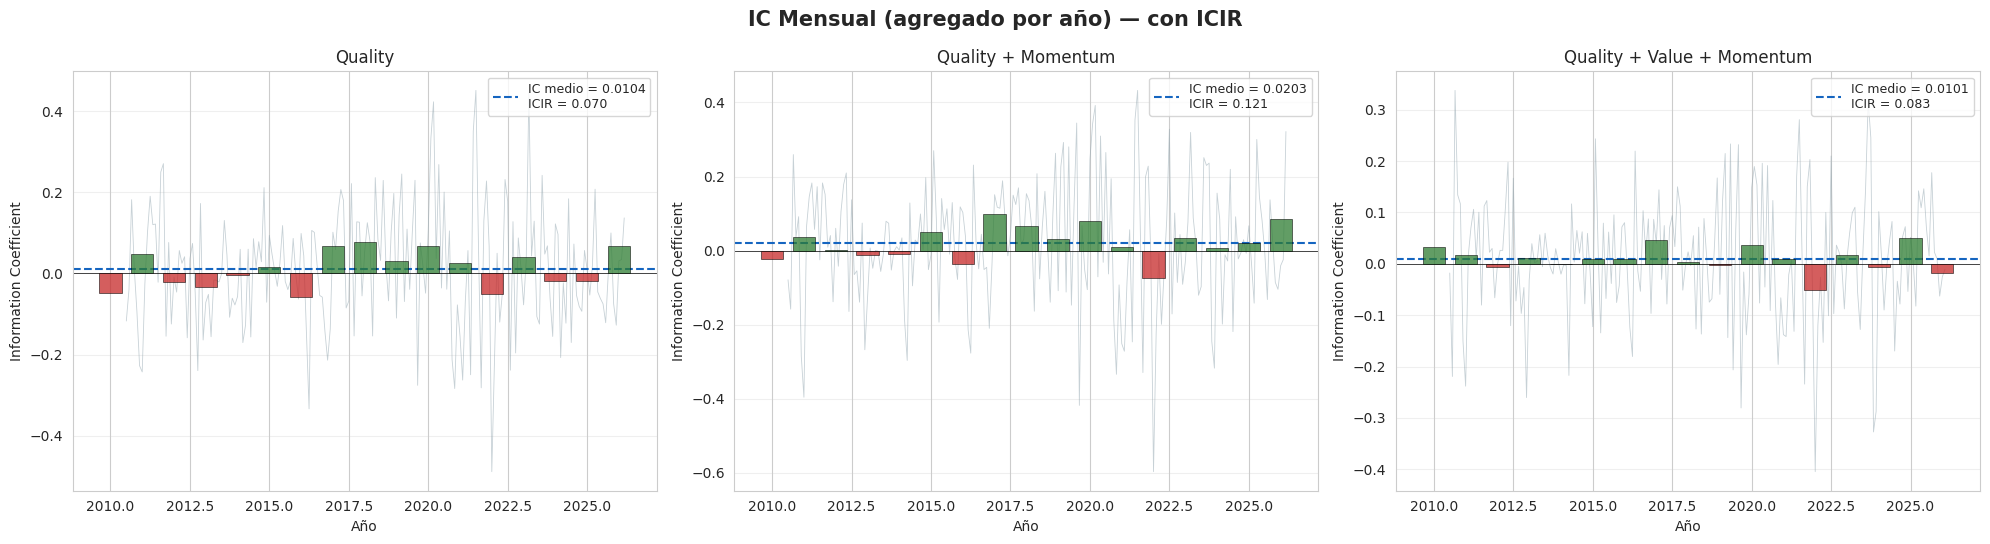

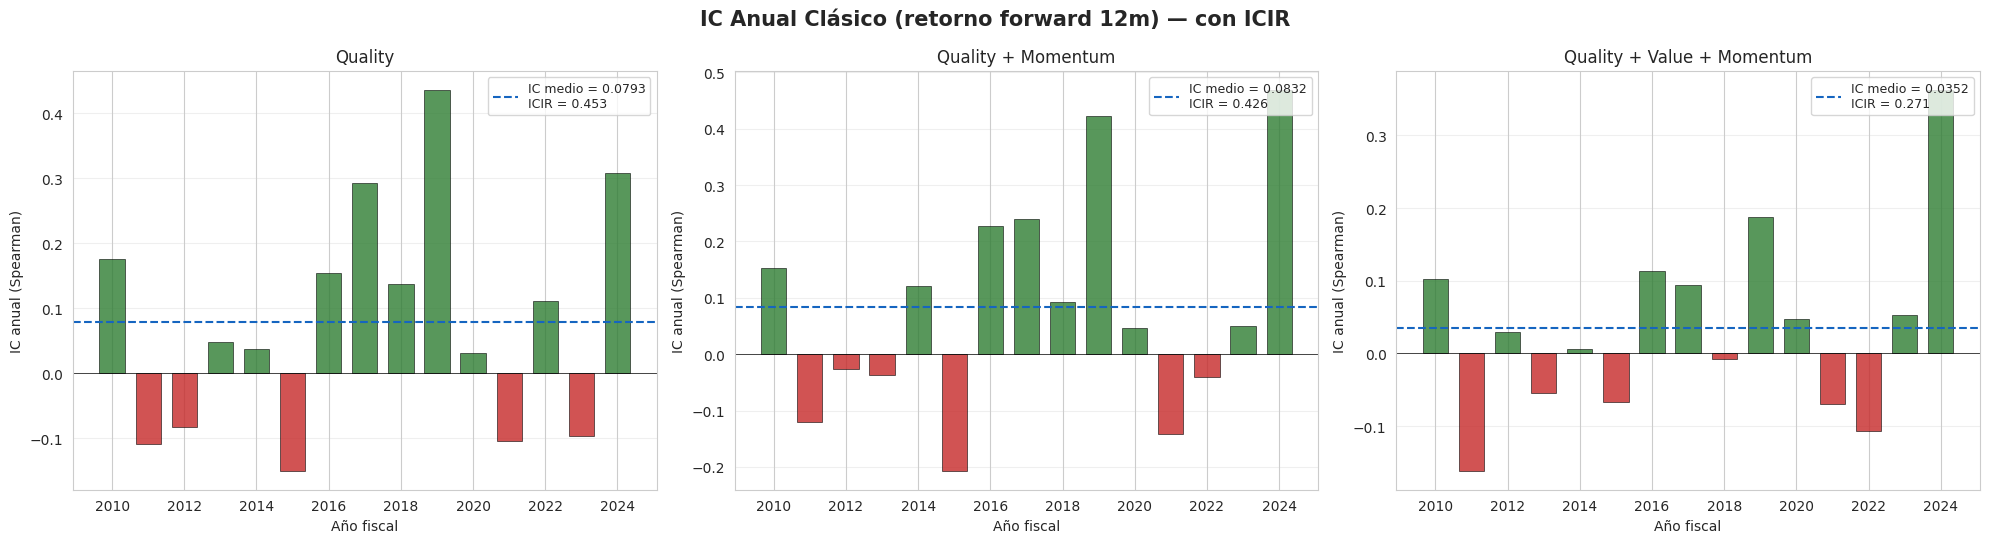

✓ D.2.f completo — gráficos de IC con ICIR


In [ ]:
# ============================================================
# SUB-BLOQUE D.2 — AGREGACIÓN ANUAL DEL IC MENSUAL + GRÁFICOS
# ============================================================
# El IC se calcula mensualmente (D.1) para significancia estadística.
# Aquí lo agregamos por AÑO CALENDARIO para presentación visual:
#   - IC medio anual = promedio de los ICs mensuales de ese año
#   - Se muestra la serie mensual de fondo para ver la granularidad
# Reutiliza 'ic_series_dict' calculado en D.1.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

score_cols = {
    'Quality':                    'score_quality_only',
    'Quality + Momentum':         'score_quality_momentum',
    'Quality + Value + Momentum': 'score_qvm',
}

# ─────────────────────────────────────────────
# D.2.a — Agregar cada serie mensual por año calendario
# ─────────────────────────────────────────────
def aggregate_ic_by_year(serie_mensual):
    """IC medio por año calendario desde la serie mensual [cal_month, IC, n_firms]."""
    s = serie_mensual.copy()
    s['year'] = pd.to_datetime(s['cal_month']).dt.year
    agg = s.groupby('year').agg(
        IC_mean=('IC', 'mean'),
        IC_std=('IC', 'std'),
        n_months=('IC', 'size'),
        n_firms_avg=('n_firms', 'mean')
    ).reset_index()
    return agg

ic_annual_agg = {}
for nombre in score_cols:
    ic_annual_agg[nombre] = aggregate_ic_by_year(ic_series_dict[nombre])

# ─────────────────────────────────────────────
# D.2.b — GRÁFICO MENSUAL (agregado por año) con ICIR
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
fig.suptitle('IC Mensual (agregado por año) — con ICIR', fontsize=15, fontweight='bold')

for idx, nombre in enumerate(score_cols):
    ax = axes[idx]
    agg = ic_annual_agg[nombre]
    serie_m = ic_series_dict[nombre].copy()
    serie_m['year_frac'] = pd.to_datetime(serie_m['cal_month']).dt.year + \
                           (pd.to_datetime(serie_m['cal_month']).dt.month - 1) / 12

    # Métricas mensuales
    ic_mean = serie_m['IC'].mean()
    ic_std  = serie_m['IC'].std()
    icir_m  = ic_mean / ic_std if ic_std > 0 else np.nan
    icir_a  = icir_m * np.sqrt(12)

    colores = ['#2e7d32' if v > 0 else '#c62828' for v in agg['IC_mean']]
    ax.bar(agg['year'], agg['IC_mean'], color=colores, alpha=0.75,
           edgecolor='black', linewidth=0.5, width=0.7, zorder=3)
    ax.plot(serie_m['year_frac'], serie_m['IC'], color='#90a4ae',
            linewidth=0.6, alpha=0.5, zorder=1)
    ax.axhline(y=ic_mean, color='#1565c0', linestyle='--', linewidth=1.5, zorder=2,
               label=f'IC medio = {ic_mean:.4f}\nICIR = {icir_m:.3f}')
    ax.axhline(y=0, color='black', linewidth=0.5, zorder=2)
    ax.set_title(nombre, fontsize=12)
    ax.set_xlabel('Año'); ax.set_ylabel('Information Coefficient')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# D.2.c — Calcular IC anual clásico (1 IC por año fiscal)
# ─────────────────────────────────────────────
# Garantizar que return_forward existe
if 'return_forward' not in df_master.columns:
    df_master = df_master.sort_values(['ric', 'fiscal_year']).reset_index(drop=True)
    df_master['price_next'] = df_master.groupby('ric')['price_close'].shift(-1)
    df_master['return_forward'] = (df_master['price_next'] / df_master['price_close'].replace(0, np.nan)) - 1

def annual_ic_series(df, score_col, ret_col='return_forward', min_firms=MIN_FIRMS_PER_YEAR):
    """Un IC por año fiscal: Spearman(score, retorno forward 12m)."""
    records = []
    sub = df.dropna(subset=[score_col, ret_col])
    for year, g in sub.groupby('fiscal_year'):
        if len(g) >= min_firms:
            res = spearmanr(g[score_col].values, g[ret_col].values)
            ic = res.statistic if hasattr(res, 'statistic') else res[0]
            records.append({'year': int(year), 'IC': ic, 'n': len(g)})
    return pd.DataFrame(records)

ic_annual_classic = {nombre: annual_ic_series(df_master, col)
                     for nombre, col in score_cols.items()}

# ─────────────────────────────────────────────
# D.2.c.2 — GRÁFICO ANUAL CLÁSICO con ICIR
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
fig.suptitle('IC Anual Clásico (retorno forward 12m) — con ICIR', fontsize=15, fontweight='bold')

for idx, nombre in enumerate(score_cols):
    ax = axes[idx]
    dfc = ic_annual_classic[nombre]

    ic_mean = dfc['IC'].mean()
    ic_std  = dfc['IC'].std()
    icir_y  = ic_mean / ic_std if ic_std > 0 else np.nan

    colores = ['#2e7d32' if v > 0 else '#c62828' for v in dfc['IC']]
    ax.bar(dfc['year'], dfc['IC'], color=colores, alpha=0.8,
           edgecolor='black', linewidth=0.5, width=0.7)
    ax.axhline(y=ic_mean, color='#1565c0', linestyle='--', linewidth=1.5,
               label=f'IC medio = {ic_mean:.4f}\nICIR = {icir_y:.3f}')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_title(nombre, fontsize=12)
    ax.set_xlabel('Año fiscal'); ax.set_ylabel('IC anual (Spearman)')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ D.2.f completo — gráficos de IC con ICIR")

  ESTABILIDAD DEL RANKING (correlación media año a año)
  Quality                     : 0.8750
  Quality + Momentum          : 0.5335
  Quality + Value + Momentum  : 0.4330


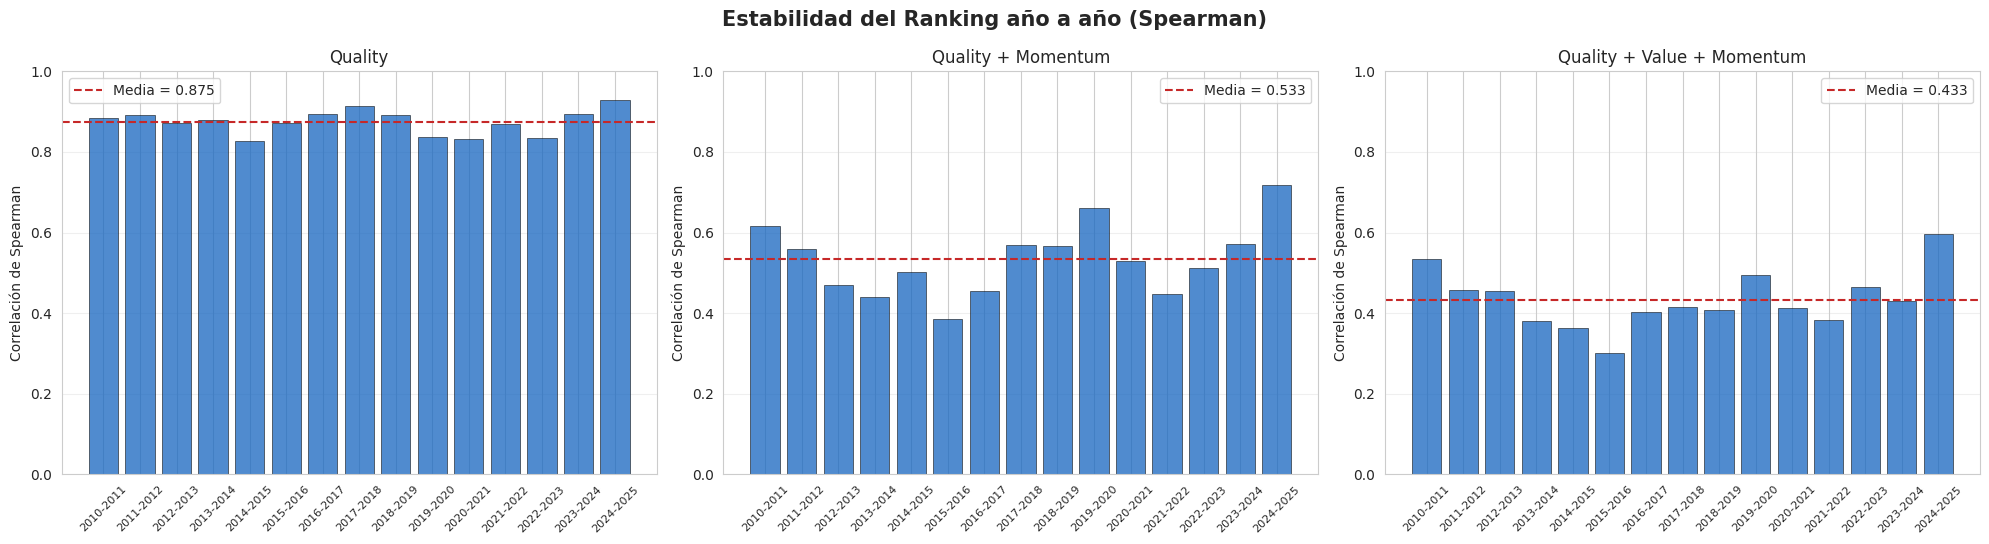


✓ D.2.g completo — estabilidad del ranking


In [ ]:
# ============================================================
# SUB-BLOQUE D.2.d — ESTABILIDAD DEL RANKING (score anual)
# ============================================================
# Mide la persistencia del ranking: correlación de Spearman entre el
# score de un año y el del año siguiente, para las mismas empresas.
# Alta estabilidad → bajo turnover → deseable para el rebalanceo del
# Bloque 2 (HRP anual).
# ============================================================

from scipy.stats import spearmanr

score_cols = {
    'Quality':                    'score_quality_only',
    'Quality + Momentum':         'score_quality_momentum',
    'Quality + Value + Momentum': 'score_qvm',
}
MIN_COMMON = 20

def ranking_stability(df, score_col, min_common=MIN_COMMON):
    """Correlación de Spearman del score año t vs año t+1 (empresas comunes)."""
    records = []
    años = sorted(df[df[score_col].notna()]['fiscal_year'].unique())
    for i in range(1, len(años)):
        prev = df[df['fiscal_year'] == años[i-1]][['ric', score_col]].dropna()
        curr = df[df['fiscal_year'] == años[i]][['ric', score_col]].dropna()
        merged = prev.merge(curr, on='ric', suffixes=('_prev', '_curr'))
        if len(merged) >= min_common:
            res = spearmanr(merged[f'{score_col}_prev'].values,
                            merged[f'{score_col}_curr'].values)
            corr = res.statistic if hasattr(res, 'statistic') else res[0]
            records.append({'par': f"{int(años[i-1])}-{int(años[i])}",
                            'corr': corr, 'n': len(merged)})
    return pd.DataFrame(records)

stability_dict = {nombre: ranking_stability(df_master, col)
                  for nombre, col in score_cols.items()}

# Tabla resumen
print("="*60)
print("  ESTABILIDAD DEL RANKING (correlación media año a año)")
print("="*60)
for nombre in score_cols:
    m = stability_dict[nombre]['corr'].mean()
    print(f"  {nombre:<28s}: {m:.4f}")

# Gráfico: 3 paneles
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
fig.suptitle('Estabilidad del Ranking año a año (Spearman)', fontsize=15, fontweight='bold')

for idx, nombre in enumerate(score_cols):
    ax = axes[idx]
    dfs = stability_dict[nombre]
    ax.bar(dfs['par'], dfs['corr'], color='#1565c0', alpha=0.75,
           edgecolor='black', linewidth=0.5)
    m = dfs['corr'].mean()
    ax.axhline(y=m, color='#c62828', linestyle='--', linewidth=1.5,
               label=f'Media = {m:.3f}')
    ax.set_ylim(0, 1)
    ax.set_title(nombre, fontsize=12)
    ax.set_ylabel('Correlación de Spearman')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ D.2.g completo — estabilidad del ranking")

In [ ]:
# ============================================================
# SUB-BLOQUE D.3 — QUINTILES Y SPREAD Q5-Q1 (mensual + anual)
# ============================================================
# Para cada estrategia:
#   CAPA MENSUAL: cada mes se ordenan las empresas por su score vigente
#     en 5 quintiles (equiponderados). Retorno mensual de cada quintil y
#     spread Q5-Q1. Significancia del spread con Newey-West (12 lags),
#     mostrando también el t-stat SIN corregir para evidenciar la inflación.
#   CAPA ANUAL: quintiles por año fiscal (equiponderados), retorno anual
#     por quintil y spread Q5-Q1 con t-test clásico (como versión anterior).
#
# Decisiones: equiponderado, spread descriptivo, Opción A (quintiles
# reasignados cada período), mínimo 30 empresas/mes y 25/año.
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import ttest_1samp

score_cols = {
    'Quality':                    'score_quality_only',
    'Quality + Momentum':         'score_quality_momentum',
    'Quality + Value + Momentum': 'score_qvm',
}
MIN_FIRMS_MONTH = 30
MIN_FIRMS_YEAR = 25
NW_LAGS = 12

def newey_west_tstat(series, lags=NW_LAGS):
    y = series.dropna().values
    X = np.ones(len(y))
    res = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    return res.params[0], res.tvalues[0], res.pvalues[0]

def simple_tstat(series):
    y = series.dropna().values
    t, p = ttest_1samp(y, 0)
    return y.mean(), t, p

# ─────────────────────────────────────────────
# D.3.a — CAPA MENSUAL: quintiles por mes calendario
# ─────────────────────────────────────────────
def monthly_quintile_analysis(panel, score_col, ret_col='ret_monthly',
                              month_col='cal_month', min_firms=MIN_FIRMS_MONTH):
    """
    Cada mes: asigna 5 quintiles por score, calcula el retorno medio
    (equiponderado) de cada quintil. Devuelve:
      - serie de retornos mensuales por quintil (para promediar)
      - serie del spread Q5-Q1 mensual (para Newey-West)
    """
    q_returns = {1: [], 2: [], 3: [], 4: [], 5: []}
    spread_series = []
    sub = panel.dropna(subset=[score_col, ret_col])

    for month, g in sub.groupby(month_col):
        if len(g) < min_firms:
            continue
        g = g.copy()
        # Asignar quintiles (1=bottom, 5=top). duplicates='drop' por si hay empates.
        try:
            g['q'] = pd.qcut(g[score_col], 5, labels=[1,2,3,4,5], duplicates='drop')
        except ValueError:
            continue
        month_means = g.groupby('q', observed=True)[ret_col].mean()
        if 1 in month_means.index and 5 in month_means.index:
            for q in [1,2,3,4,5]:
                if q in month_means.index:
                    q_returns[q].append(month_means[q])
            spread_series.append({'cal_month': month,
                                  'spread': month_means[5] - month_means[1]})
    return q_returns, pd.DataFrame(spread_series)

# ─────────────────────────────────────────────
# D.3.b — CAPA ANUAL: quintiles por año fiscal
# ─────────────────────────────────────────────
def annual_quintile_analysis(df, score_col, ret_col='return_forward',
                             min_firms=MIN_FIRMS_YEAR):
    """Quintiles por año fiscal, retorno anual por quintil y spread Q5-Q1."""
    q_returns = {1: [], 2: [], 3: [], 4: [], 5: []}
    spread_series = []
    sub = df.dropna(subset=[score_col, ret_col])
    for year, g in sub.groupby('fiscal_year'):
        if len(g) < min_firms:
            continue
        g = g.copy()
        try:
            g['q'] = pd.qcut(g[score_col], 5, labels=[1,2,3,4,5], duplicates='drop')
        except ValueError:
            continue
        ymeans = g.groupby('q', observed=True)[ret_col].mean()
        if 1 in ymeans.index and 5 in ymeans.index:
            for q in [1,2,3,4,5]:
                if q in ymeans.index:
                    q_returns[q].append(ymeans[q])
            spread_series.append({'year': int(year), 'spread': ymeans[5]-ymeans[1]})
    return q_returns, pd.DataFrame(spread_series)

# Asegurar return_forward
if 'return_forward' not in df_master.columns:
    df_master = df_master.sort_values(['ric','fiscal_year']).reset_index(drop=True)
    df_master['price_next'] = df_master.groupby('ric')['price_close'].shift(-1)
    df_master['return_forward'] = (df_master['price_next']/df_master['price_close'].replace(0,np.nan)) - 1

# ─────────────────────────────────────────────
# D.3.c — Ejecutar y reportar
# ─────────────────────────────────────────────
quintile_results = {}   # guardamos para gráficos posteriores

print("="*80)
print("  SUB-BLOQUE D.3 — QUINTILES Y SPREAD Q5-Q1")
print("="*80)

for nombre, col in score_cols.items():
    # MENSUAL
    q_ret_m, spread_m = monthly_quintile_analysis(panel_monthly, col)
    q_means_m = {q: np.mean(v) for q, v in q_ret_m.items() if len(v) > 0}
    sp_mean_m, sp_t_nw, sp_p_nw = newey_west_tstat(spread_m['spread'])
    _, sp_t_simple, sp_p_simple = simple_tstat(spread_m['spread'])

    # ANUAL
    q_ret_y, spread_y = annual_quintile_analysis(df_master, col)
    q_means_y = {q: np.mean(v) for q, v in q_ret_y.items() if len(v) > 0}
    sp_mean_y, sp_t_y, sp_p_y = simple_tstat(spread_y['spread'])
    pct_y_pos = (spread_y['spread'] > 0).mean() * 100

    quintile_results[nombre] = {
        'q_means_m': q_means_m, 'spread_m': spread_m,
        'q_means_y': q_means_y, 'spread_y': spread_y,
    }

    def stars(p): return "***" if p<0.01 else ("**" if p<0.05 else ("*" if p<0.10 else ""))

    print(f"\n{'─'*80}")
    print(f"  {nombre}")
    print(f"{'─'*80}")

    # Mensual
    print(f"  MENSUAL (equiponderado, {len(spread_m)} meses):")
    print(f"    Retorno mensual por quintil:")
    for q in [1,2,3,4,5]:
        if q in q_means_m:
            tag = " (Junk)" if q==1 else (" (Quality)" if q==5 else "")
            print(f"      Q{q}{tag:<10s}: {q_means_m[q]*100:6.3f}%")
    print(f"    Spread Q5-Q1 mensual: {sp_mean_m*100:.3f}%")
    print(f"      t-stat SIN corregir:  {sp_t_simple:6.3f}  (p={sp_p_simple:.4f}) {stars(sp_p_simple)}")
    print(f"      t-stat Newey-West:    {sp_t_nw:6.3f}  (p={sp_p_nw:.4f}) {stars(sp_p_nw)}")
    print(f"      → inflación sin corregir: factor {abs(sp_t_simple/sp_t_nw):.2f}x")

    # Anual
    print(f"\n  ANUAL (equiponderado, {len(spread_y)} años):")
    print(f"    Retorno anual por quintil:")
    for q in [1,2,3,4,5]:
        if q in q_means_y:
            tag = " (Junk)" if q==1 else (" (Quality)" if q==5 else "")
            print(f"      Q{q}{tag:<10s}: {q_means_y[q]*100:6.2f}%")
    print(f"    Spread Q5-Q1 anual: {sp_mean_y*100:.2f}%  |  % años Q5>Q1: {pct_y_pos:.0f}%")
    print(f"      t-stat clásico: {sp_t_y:6.3f}  (p={sp_p_y:.4f}) {stars(sp_p_y)}")

print(f"\n{'='*80}")
print("  *** p<0.01, ** p<0.05, * p<0.10  |  Resultados en 'quintile_results'")
print("="*80)

  SUB-BLOQUE D.3 — QUINTILES Y SPREAD Q5-Q1

────────────────────────────────────────────────────────────────────────────────
  Quality
────────────────────────────────────────────────────────────────────────────────
  MENSUAL (equiponderado, 189 meses):
    Retorno mensual por quintil:
      Q1 (Junk)   :  1.186%
      Q2          :  1.070%
      Q3          :  1.058%
      Q4          :  1.138%
      Q5 (Quality):  1.308%
    Spread Q5-Q1 mensual: 0.122%
      t-stat SIN corregir:   0.452  (p=0.6515) 
      t-stat Newey-West:     0.481  (p=0.6306) 
      → inflación sin corregir: factor 0.94x

  ANUAL (equiponderado, 15 años):
    Retorno anual por quintil:
      Q1 (Junk)   :  11.72%
      Q2          :  10.58%
      Q3          :  12.78%
      Q4          :  15.52%
      Q5 (Quality):  18.21%
    Spread Q5-Q1 anual: 6.49%  |  % años Q5>Q1: 67%
      t-stat clásico:  1.448  (p=0.1696) 

────────────────────────────────────────────────────────────────────────────────
  Quality + Mome

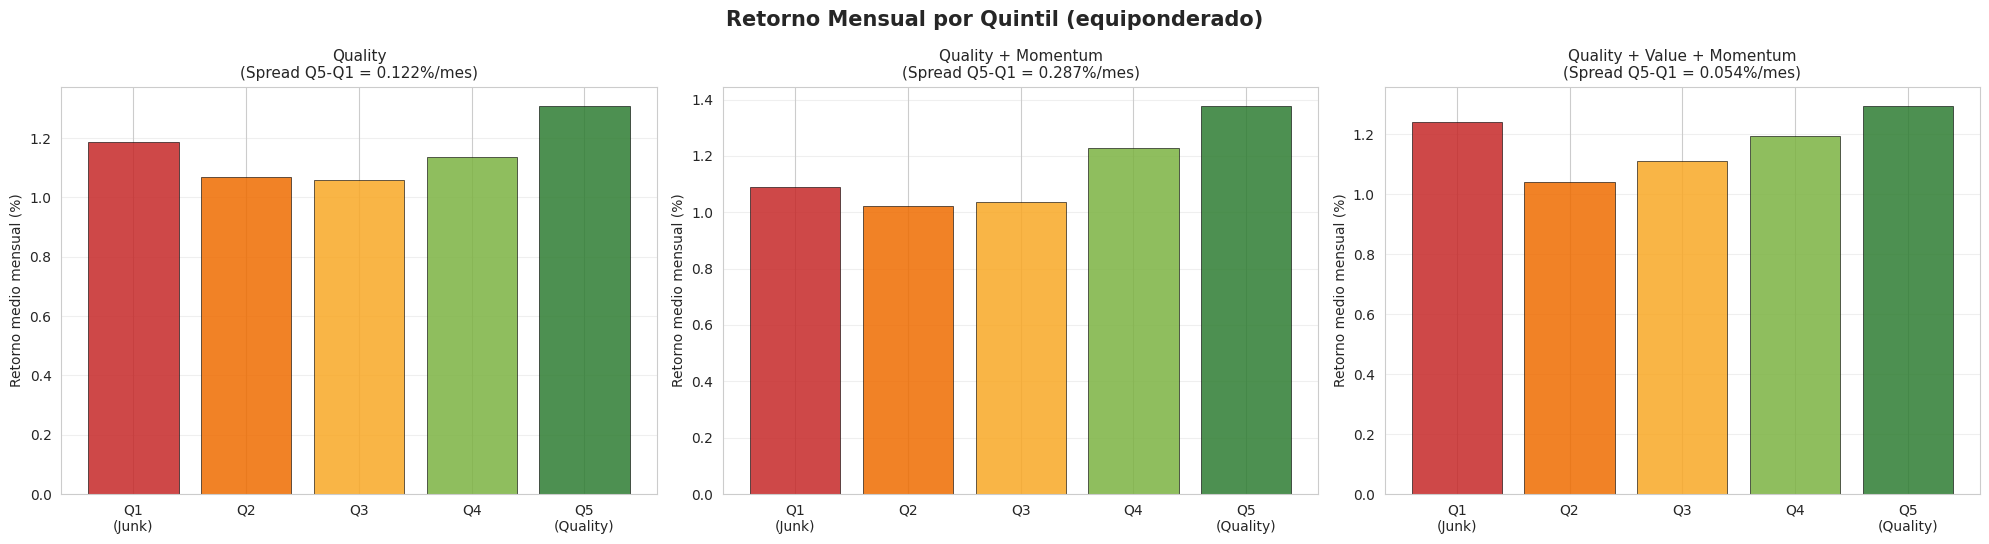

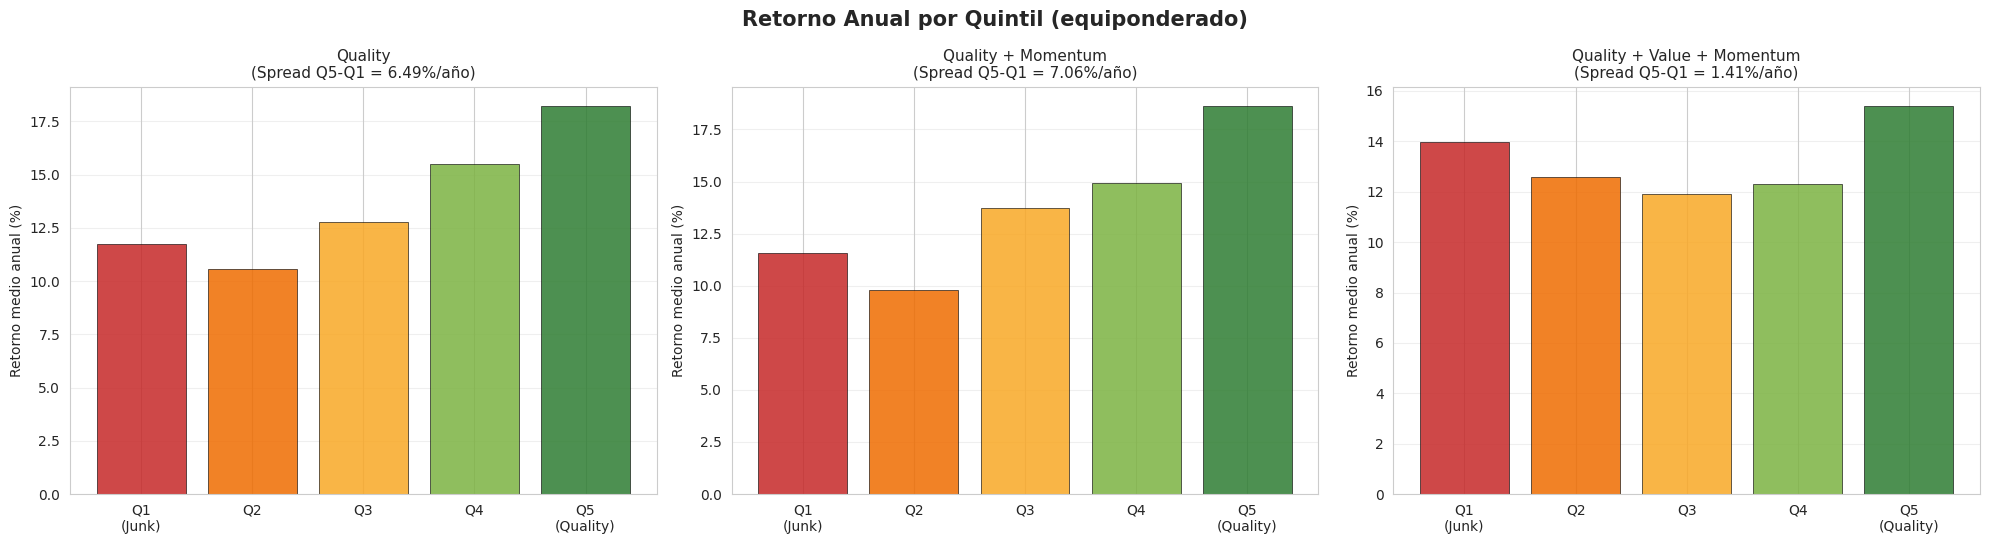

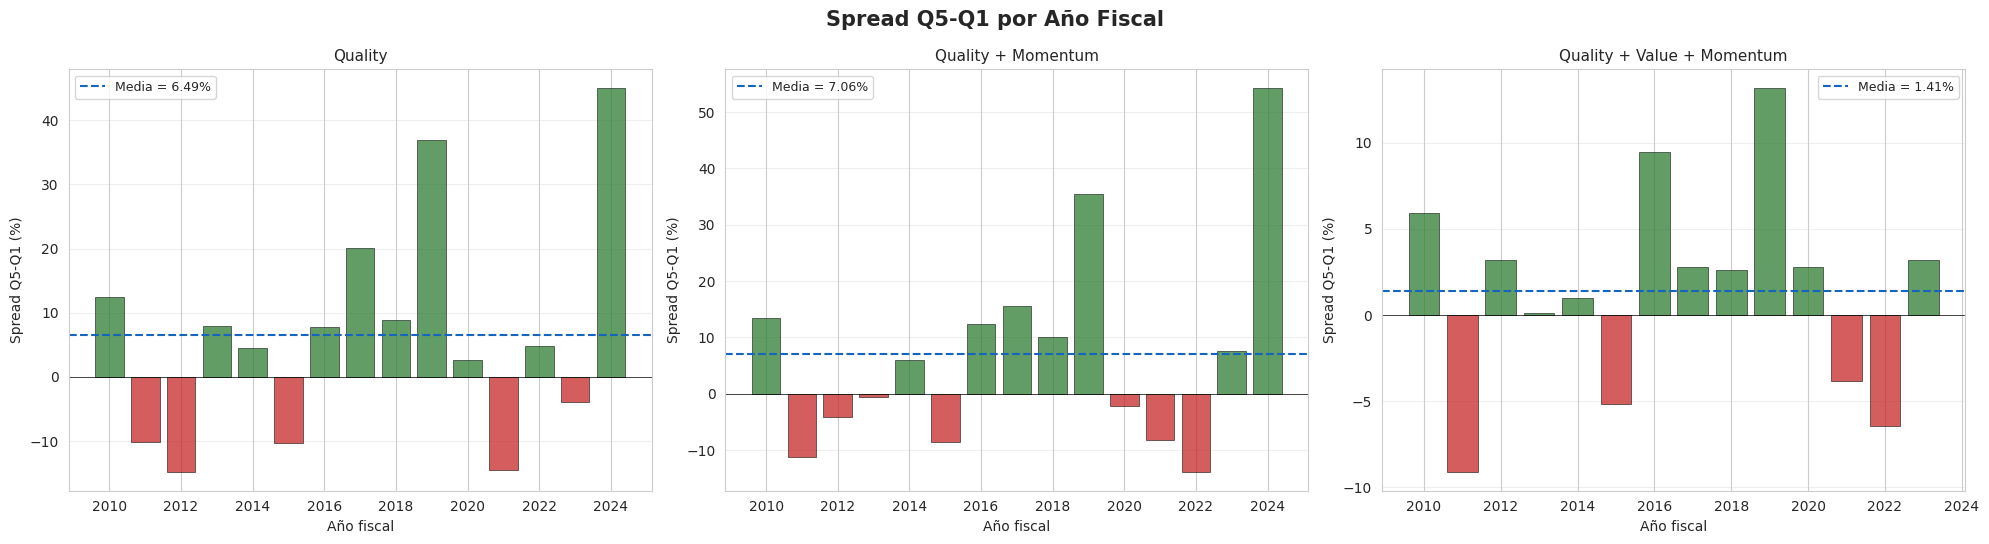

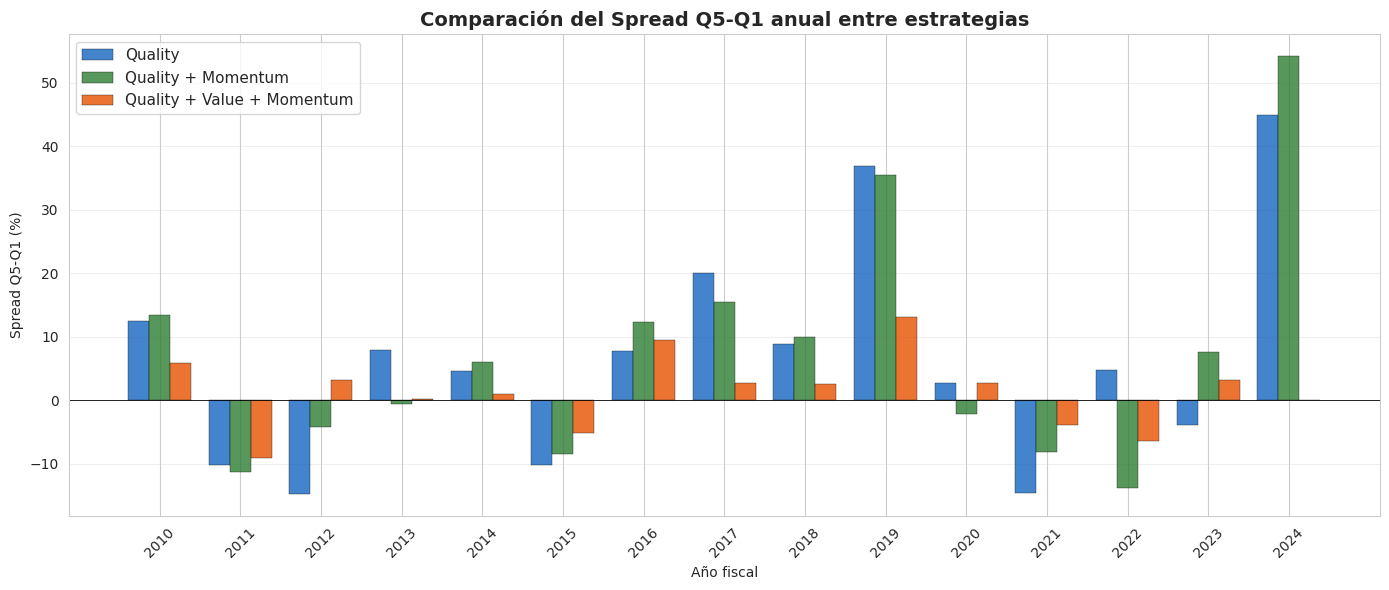

✓ Gráficos de D.3 completos


In [ ]:
# ============================================================
# SUB-BLOQUE D.3 — GRÁFICOS (reutiliza quintile_results)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

score_names = ['Quality', 'Quality + Momentum', 'Quality + Value + Momentum']
colores_q = ['#c62828', '#ef6c00', '#f9a825', '#7cb342', '#2e7d32']  # Q1..Q5

# ─────────────────────────────────────────────
# GRÁFICO 1 — Retorno por quintil, MENSUAL (3 paneles)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
fig.suptitle('Retorno Mensual por Quintil (equiponderado)', fontsize=15, fontweight='bold')

for idx, nombre in enumerate(score_names):
    ax = axes[idx]
    qm = quintile_results[nombre]['q_means_m']
    valores = [qm[q]*100 for q in [1,2,3,4,5]]
    spread = (qm[5]-qm[1])*100
    ax.bar(['Q1\n(Junk)','Q2','Q3','Q4','Q5\n(Quality)'], valores,
           color=colores_q, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_title(f'{nombre}\n(Spread Q5-Q1 = {spread:.3f}%/mes)', fontsize=11)
    ax.set_ylabel('Retorno medio mensual (%)')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# GRÁFICO 2 — Retorno por quintil, ANUAL (3 paneles)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
fig.suptitle('Retorno Anual por Quintil (equiponderado)', fontsize=15, fontweight='bold')

for idx, nombre in enumerate(score_names):
    ax = axes[idx]
    qy = quintile_results[nombre]['q_means_y']
    valores = [qy[q]*100 for q in [1,2,3,4,5]]
    spread = (qy[5]-qy[1])*100
    ax.bar(['Q1\n(Junk)','Q2','Q3','Q4','Q5\n(Quality)'], valores,
           color=colores_q, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_title(f'{nombre}\n(Spread Q5-Q1 = {spread:.2f}%/año)', fontsize=11)
    ax.set_ylabel('Retorno medio anual (%)')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# GRÁFICO 3 — Spread Q5-Q1 por año fiscal (3 paneles)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
fig.suptitle('Spread Q5-Q1 por Año Fiscal', fontsize=15, fontweight='bold')

for idx, nombre in enumerate(score_names):
    ax = axes[idx]
    sp = quintile_results[nombre]['spread_y']
    colores_sp = ['#2e7d32' if v > 0 else '#c62828' for v in sp['spread']]
    ax.bar(sp['year'], sp['spread']*100, color=colores_sp, alpha=0.75,
           edgecolor='black', linewidth=0.5)
    m = sp['spread'].mean()*100
    ax.axhline(y=m, color='#1565c0', linestyle='--', linewidth=1.5,
               label=f'Media = {m:.2f}%')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel('Año fiscal'); ax.set_ylabel('Spread Q5-Q1 (%)')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# GRÁFICO 4 — Comparativo del spread anual entre estrategias
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
colores_estrat = {'Quality': '#1565c0',
                  'Quality + Momentum': '#2e7d32',
                  'Quality + Value + Momentum': '#e65100'}

años_all = sorted(set().union(*[set(quintile_results[n]['spread_y']['year']) for n in score_names]))
x = np.arange(len(años_all))
width = 0.26

for i, nombre in enumerate(score_names):
    sp = quintile_results[nombre]['spread_y'].set_index('year')
    valores = [sp.loc[a,'spread']*100 if a in sp.index else 0 for a in años_all]
    ax.bar(x + (i-1)*width, valores, width, label=nombre,
           color=colores_estrat[nombre], alpha=0.8, edgecolor='black', linewidth=0.3)

ax.axhline(y=0, color='black', linewidth=0.6)
ax.set_xticks(x); ax.set_xticklabels([int(a) for a in años_all], rotation=45)
ax.set_xlabel('Año fiscal'); ax.set_ylabel('Spread Q5-Q1 (%)')
ax.set_title('Comparación del Spread Q5-Q1 anual entre estrategias', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Gráficos de D.3 completos")

In [ ]:
# ============================================================
# BLOQUE F.1 — DESCARGA DE FACTORES FAMA-FRENCH
# ============================================================
# Descarga los factores mensuales de la librería oficial de Kenneth
# French (Dartmouth), vía pandas_datareader. No requiere credenciales.
#   - Mkt-RF: retorno del mercado en exceso de la tasa libre de riesgo
#   - SMB: Small Minus Big (factor tamaño)
#   - HML: High Minus Low (factor value)
#   - RF: tasa libre de riesgo mensual
# Estos factores permiten estimar el alpha (CAPM y Fama-French 3 factores)
# de los portfolios de quintiles del Bloque D.
# ============================================================

# Instalar pandas_datareader si no está
try:
    import pandas_datareader.data as web
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'pandas_datareader', '-q'])
    import pandas_datareader.data as web

import pandas as pd
import numpy as np
import datetime

# ─────────────────────────────────────────────
# F.1.1 — Descargar Fama-French 3 factores (mensual)
# ─────────────────────────────────────────────
# El dataset se llama 'F-F_Research_Data_Factors' (mensual).
# Los valores vienen en PORCENTAJE (ej. 1.23 = 1.23%), hay que dividir /100.

print("F.1 — Descargando factores Fama-French (Kenneth French Data Library)...")

start = datetime.datetime(2005, 1, 1)
end = datetime.datetime(2026, 12, 31)

ff = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start, end)

# ff[0] es la tabla mensual; ff[1] sería anual
ff_monthly = ff[0].copy()
print(f"  Descarga OK. Período: {ff_monthly.index.min()} a {ff_monthly.index.max()}")
print(f"  Columnas: {list(ff_monthly.columns)}")

# ─────────────────────────────────────────────
# F.1.2 — Normalizar formato
# ─────────────────────────────────────────────
# Convertir de porcentaje a decimal
ff_monthly = ff_monthly / 100.0

# Renombrar columnas a nombres limpios
ff_monthly.columns = [c.strip().replace('-', '_') for c in ff_monthly.columns]
# Típicamente queda: Mkt_RF, SMB, HML, RF

# Convertir el índice (PeriodIndex mensual) a timestamp de inicio de mes
ff_monthly.index = ff_monthly.index.to_timestamp()
ff_monthly.index = ff_monthly.index.values.astype('datetime64[M]')
ff_monthly = ff_monthly.reset_index().rename(columns={'index': 'cal_month'})
ff_monthly['cal_month'] = pd.to_datetime(ff_monthly['cal_month'])

print(f"\n  Formato normalizado. Columnas finales: {list(ff_monthly.columns)}")

# ─────────────────────────────────────────────
# F.1.3 — Validación y estadísticas de control
# ─────────────────────────────────────────────
print(f"\nF.1.3 — Estadísticas de control (valores mensuales, decimal):")
print(f"  Nº meses: {len(ff_monthly)}")
print(f"  Rango: {ff_monthly['cal_month'].min().date()} a {ff_monthly['cal_month'].max().date()}")
print(f"\n  {'Factor':<10s} {'media':>10s} {'std':>10s} {'min':>10s} {'max':>10s}")
for col in ['Mkt_RF', 'SMB', 'HML', 'RF']:
    if col in ff_monthly.columns:
        s = ff_monthly[col]
        print(f"  {col:<10s} {s.mean()*100:>9.3f}% {s.std()*100:>9.3f}% "
              f"{s.min()*100:>9.2f}% {s.max()*100:>9.2f}%")

# Solapamiento temporal con nuestro panel
panel_months = pd.to_datetime(panel_monthly['cal_month']).dt.to_period('M').unique()
ff_months = pd.to_datetime(ff_monthly['cal_month']).dt.to_period('M').unique()
overlap = set(panel_months) & set(ff_months)
print(f"\n  Solapamiento con panel_monthly:")
print(f"    Meses en nuestro panel: {len(panel_months)}")
print(f"    Meses en Fama-French:   {len(ff_months)}")
print(f"    Meses en común:         {len(overlap)}")

print(f"\n✓ F.1 completo — factores en 'ff_monthly'")

F.1 — Descargando factores Fama-French (Kenneth French Data Library)...
  Descarga OK. Período: 2005-01 a 2026-05
  Columnas: ['Mkt-RF', 'SMB', 'HML', 'RF']

  Formato normalizado. Columnas finales: ['cal_month', 'Mkt_RF', 'SMB', 'HML', 'RF']

F.1.3 — Estadísticas de control (valores mensuales, decimal):
  Nº meses: 257
  Rango: 2005-01-01 a 2026-05-01

  Factor          media        std        min        max
  Mkt_RF         0.840%     4.439%    -17.20%     13.60%
  SMB           -0.049%     2.482%     -5.93%      7.14%
  HML           -0.033%     3.186%    -13.83%     12.86%
  RF             0.142%     0.161%      0.00%      0.48%

  Solapamiento con panel_monthly:
    Meses en nuestro panel: 238
    Meses en Fama-French:   257
    Meses en común:         238

✓ F.1 completo — factores en 'ff_monthly'


In [ ]:
# ============================================================
# BLOQUE F.2 — REGRESIONES DE ALPHA (CAPM + FAMA-FRENCH 3F)
# ============================================================
# Para cada estrategia, construye dos portfolios mensuales equiponderados:
#   - Q5 (top quality): en exceso de RF
#   - Q5-Q1 (spread): diferencia top-bottom (aprox. market-neutral)
# y estima:
#   - CAPM:  R - Rf = alpha + beta·(Mkt-Rf) + e
#   - FF3:   R - Rf = alpha + b1·(Mkt-Rf) + b2·SMB + b3·HML + e
# Errores estándar Newey-West (12 lags) para el alpha y las betas.
#
# El alpha (intercepto) es la métrica clave: retorno no explicado por la
# exposición al mercado (CAPM) ni a los factores tamaño/value (FF3).
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm

score_cols = {
    'Quality':                    'score_quality_only',
    'Quality + Momentum':         'score_quality_momentum',
    'Quality + Value + Momentum': 'score_qvm',
}
MIN_FIRMS_MONTH = 30
NW_LAGS = 12

# ─────────────────────────────────────────────
# F.2.1 — Construir series mensuales de retorno de Q5 y Q5-Q1
# ─────────────────────────────────────────────
def build_portfolio_returns(panel, score_col, ret_col='ret_monthly',
                            month_col='cal_month', min_firms=MIN_FIRMS_MONTH):
    """
    Para cada mes: quintiles equiponderados por score vigente.
    Devuelve DataFrame [cal_month, ret_Q5, ret_Q1, ret_spread].
    """
    records = []
    sub = panel.dropna(subset=[score_col, ret_col])
    for month, g in sub.groupby(month_col):
        if len(g) < min_firms:
            continue
        g = g.copy()
        try:
            g['q'] = pd.qcut(g[score_col], 5, labels=[1,2,3,4,5], duplicates='drop')
        except ValueError:
            continue
        means = g.groupby('q', observed=True)[ret_col].mean()
        if 1 in means.index and 5 in means.index:
            records.append({
                'cal_month': month,
                'ret_Q5': means[5],
                'ret_Q1': means[1],
                'ret_spread': means[5] - means[1],
            })
    return pd.DataFrame(records)

# ─────────────────────────────────────────────
# F.2.2 — Función de regresión con Newey-West
# ─────────────────────────────────────────────
def run_factor_regression(y, X_factors, lags=NW_LAGS):
    """
    Regresa y contra X_factors (con constante), errores Newey-West.
    Devuelve dict con alpha, t_alpha, p_alpha, betas, R2.
    """
    X = sm.add_constant(X_factors)
    res = sm.OLS(y, X, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    out = {
        'alpha': res.params['const'],
        't_alpha': res.tvalues['const'],
        'p_alpha': res.pvalues['const'],
        'R2': res.rsquared,
        'betas': {c: res.params[c] for c in X_factors.columns},
        't_betas': {c: res.tvalues[c] for c in X_factors.columns},
    }
    return out

def stars(p):
    return "***" if p<0.01 else ("**" if p<0.05 else ("*" if p<0.10 else ""))

# ─────────────────────────────────────────────
# F.2.3 — Ejecutar para las 3 estrategias
# ─────────────────────────────────────────────
alpha_results = {}

print("="*80)
print("  BLOQUE F.2 — ALPHA (CAPM y Fama-French 3 factores), mensual, Newey-West")
print("="*80)

for nombre, col in score_cols.items():
    # Retornos de portfolios
    port = build_portfolio_returns(panel_monthly, col)
    # Merge con factores Fama-French por mes
    port['cal_month'] = pd.to_datetime(port['cal_month'])
    merged = port.merge(ff_monthly, on='cal_month', how='inner')

    # Retorno de Q5 en exceso de RF
    merged['Q5_excess'] = merged['ret_Q5'] - merged['RF']
    # El spread ya es market-neutral aproximado (no se le resta RF)
    merged['spread'] = merged['ret_spread']

    factores_capm = merged[['Mkt_RF']]
    factores_ff3 = merged[['Mkt_RF', 'SMB', 'HML']]

    print(f"\n{'─'*80}")
    print(f"  {nombre}  ({len(merged)} meses)")
    print(f"{'─'*80}")

    alpha_results[nombre] = {}

    # ---- PORTFOLIO Q5 (top quality) ----
    print(f"\n  ▸ Portfolio Q5 (top quality), retorno en exceso de RF:")
    capm_q5 = run_factor_regression(merged['Q5_excess'], factores_capm)
    ff3_q5  = run_factor_regression(merged['Q5_excess'], factores_ff3)
    alpha_results[nombre]['Q5_capm'] = capm_q5
    alpha_results[nombre]['Q5_ff3'] = ff3_q5

    print(f"    CAPM:  alpha={capm_q5['alpha']*100:.3f}%/mes  "
          f"t={capm_q5['t_alpha']:.2f}{stars(capm_q5['p_alpha'])}  "
          f"beta_mkt={capm_q5['betas']['Mkt_RF']:.2f}  R²={capm_q5['R2']:.2f}")
    print(f"    FF3:   alpha={ff3_q5['alpha']*100:.3f}%/mes  "
          f"t={ff3_q5['t_alpha']:.2f}{stars(ff3_q5['p_alpha'])}  R²={ff3_q5['R2']:.2f}")
    print(f"           betas: Mkt={ff3_q5['betas']['Mkt_RF']:.2f}, "
          f"SMB={ff3_q5['betas']['SMB']:.2f}, HML={ff3_q5['betas']['HML']:.2f}")

    # ---- PORTFOLIO Q5-Q1 (spread) ----
    print(f"\n  ▸ Portfolio Q5-Q1 (spread, aprox. market-neutral):")
    capm_sp = run_factor_regression(merged['spread'], factores_capm)
    ff3_sp  = run_factor_regression(merged['spread'], factores_ff3)
    alpha_results[nombre]['spread_capm'] = capm_sp
    alpha_results[nombre]['spread_ff3'] = ff3_sp

    print(f"    CAPM:  alpha={capm_sp['alpha']*100:.3f}%/mes  "
          f"t={capm_sp['t_alpha']:.2f}{stars(capm_sp['p_alpha'])}  "
          f"beta_mkt={capm_sp['betas']['Mkt_RF']:.2f}  R²={capm_sp['R2']:.2f}")
    print(f"    FF3:   alpha={ff3_sp['alpha']*100:.3f}%/mes  "
          f"t={ff3_sp['t_alpha']:.2f}{stars(ff3_sp['p_alpha'])}  R²={ff3_sp['R2']:.2f}")
    print(f"           betas: Mkt={ff3_sp['betas']['Mkt_RF']:.2f}, "
          f"SMB={ff3_sp['betas']['SMB']:.2f}, HML={ff3_sp['betas']['HML']:.2f}")

# ─────────────────────────────────────────────
# F.2.4 — Tabla resumen de alphas
# ─────────────────────────────────────────────
print(f"\n\n{'='*80}")
print("  TABLA RESUMEN — ALPHA FAMA-FRENCH 3 FACTORES (%/mes anualizado)")
print(f"{'='*80}")
print(f"\n  {'Estrategia':<28s} {'Q5 alpha':>12s} {'Q5 t':>7s} {'Q5-Q1 alpha':>13s} {'Q5-Q1 t':>8s}")
print("  " + "-"*72)
for nombre in score_cols:
    a_q5 = alpha_results[nombre]['Q5_ff3']['alpha'] * 12 * 100
    t_q5 = alpha_results[nombre]['Q5_ff3']['t_alpha']
    a_sp = alpha_results[nombre]['spread_ff3']['alpha'] * 12 * 100
    t_sp = alpha_results[nombre]['spread_ff3']['t_alpha']
    print(f"  {nombre:<28s} {a_q5:>11.2f}% {t_q5:>7.2f} {a_sp:>12.2f}% {t_sp:>8.2f}")

print(f"\n  Nota: alpha anualizado (×12). *** p<0.01, ** p<0.05, * p<0.10")
print(f"  Resultados completos en 'alpha_results'")
print("="*80)

  BLOQUE F.2 — ALPHA (CAPM y Fama-French 3 factores), mensual, Newey-West

────────────────────────────────────────────────────────────────────────────────
  Quality  (189 meses)
────────────────────────────────────────────────────────────────────────────────

  ▸ Portfolio Q5 (top quality), retorno en exceso de RF:
    CAPM:  alpha=0.081%/mes  t=0.73  beta_mkt=1.01  R²=0.92
    FF3:   alpha=0.114%/mes  t=1.34  R²=0.93
           betas: Mkt=0.99, SMB=0.12, HML=-0.10

  ▸ Portfolio Q5-Q1 (spread, aprox. market-neutral):
    CAPM:  alpha=0.431%/mes  t=1.32  beta_mkt=-0.28  R²=0.10
    FF3:   alpha=0.288%/mes  t=2.19**  R²=0.66
           betas: Mkt=-0.21, SMB=-0.28, HML=-0.80

────────────────────────────────────────────────────────────────────────────────
  Quality + Momentum  (189 meses)
────────────────────────────────────────────────────────────────────────────────

  ▸ Portfolio Q5 (top quality), retorno en exceso de RF:
    CAPM:  alpha=0.105%/mes  t=1.16  beta_mkt=1.05  R²=0.90
  

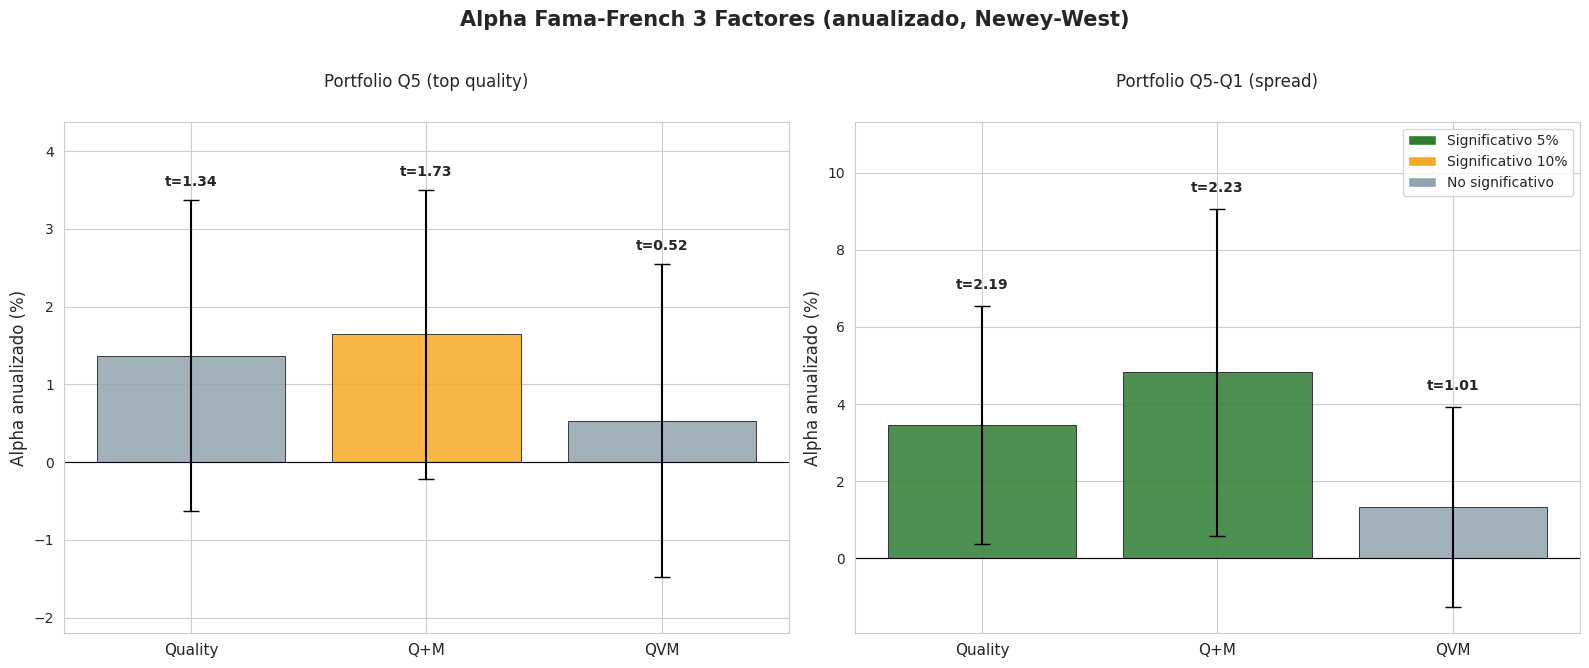

✓ Gráfico 1 del Bloque F corregido


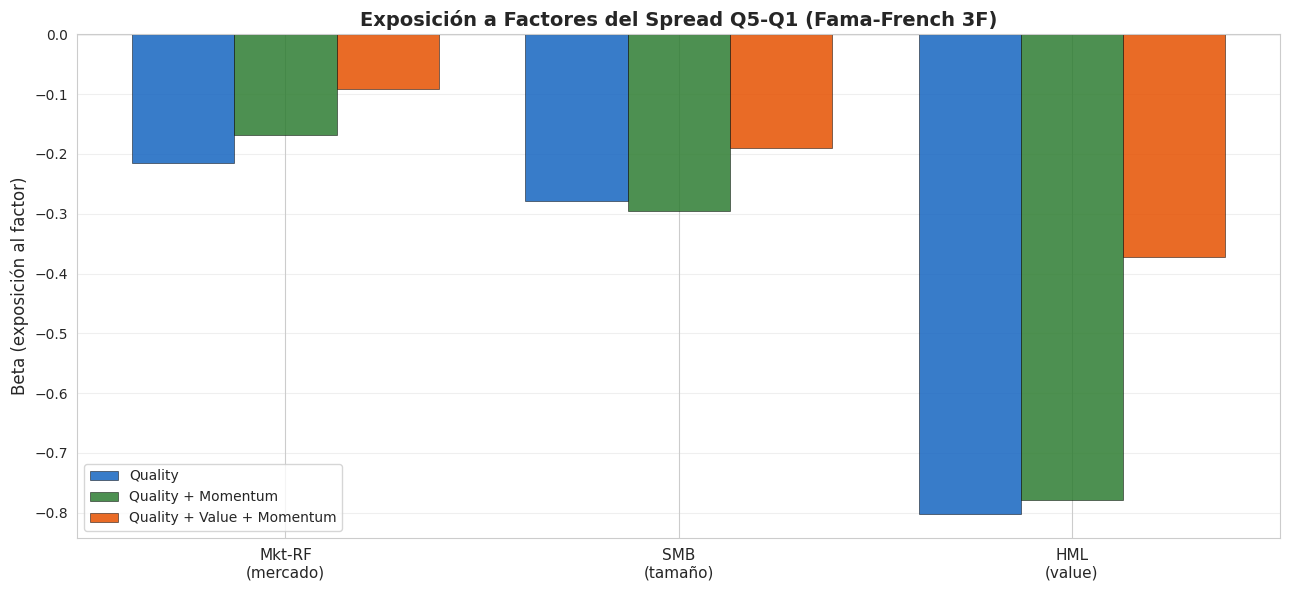

✓ Gráficos del Bloque F completos


In [ ]:
# ============================================================
# BLOQUE F — GRÁFICO 1 CORREGIDO (alphas con IC 95%)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

score_names = ['Quality', 'Quality + Momentum', 'Quality + Value + Momentum']

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.suptitle('Alpha Fama-French 3 Factores (anualizado, Newey-West)',
             fontsize=15, fontweight='bold', y=1.02)

for ax, portfolio, titulo in [
    (axes[0], 'Q5_ff3', 'Portfolio Q5 (top quality)'),
    (axes[1], 'spread_ff3', 'Portfolio Q5-Q1 (spread)')
]:
    alphas, errs, tstats, colores = [], [], [], []
    for nombre in score_names:
        r = alpha_results[nombre][portfolio]
        a_anual = r['alpha'] * 12 * 100
        t = r['t_alpha']
        se_anual = abs(a_anual / t) if t != 0 else 0
        alphas.append(a_anual)
        errs.append(1.96 * se_anual)
        tstats.append(t)
        p = r['p_alpha']
        if p < 0.05:   colores.append('#2e7d32')
        elif p < 0.10: colores.append('#f9a825')
        else:          colores.append('#90a4ae')

    x = np.arange(len(score_names))
    ax.bar(x, alphas, yerr=errs, capsize=6, color=colores, alpha=0.85,
           edgecolor='black', linewidth=0.6, error_kw={'linewidth': 1.5})
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(['Quality', 'Q+M', 'QVM'], fontsize=11)
    ax.set_ylabel('Alpha anualizado (%)', fontsize=12)
    ax.set_title(titulo, fontsize=12, pad=25)   # más espacio bajo el título

    # Dar headroom extra arriba para que las etiquetas no toquen el título
    y_top = max([a + e for a, e in zip(alphas, errs)])
    y_bot = min([a - e for a, e in zip(alphas, errs)] + [0])
    ax.set_ylim(y_bot - abs(y_bot)*0.15 - 0.5, y_top * 1.25)

    # Etiqueta t-stat: siempre justo encima del extremo superior de la barra de error,
    # pero por debajo del headroom del título
    for i, (a, e, t) in enumerate(zip(alphas, errs, tstats)):
        y_label = a + e + (y_top * 0.04)
        ax.text(i, y_label, f't={t:.2f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

legend_elems = [
    Patch(facecolor='#2e7d32', label='Significativo 5%'),
    Patch(facecolor='#f9a825', label='Significativo 10%'),
    Patch(facecolor='#90a4ae', label='No significativo'),
]
axes[1].legend(handles=legend_elems, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print("✓ Gráfico 1 del Bloque F corregido")

# ─────────────────────────────────────────────
# GRÁFICO 2 — Betas de factores del spread Q5-Q1 (FF3)
# ─────────────────────────────────────────────
# Muestra de dónde viene el retorno: exposición a Mkt, SMB, HML
fig, ax = plt.subplots(figsize=(13, 6))

factores = ['Mkt_RF', 'SMB', 'HML']
x = np.arange(len(factores))
width = 0.26
colores_estrat = {'Quality': '#1565c0',
                  'Quality + Momentum': '#2e7d32',
                  'Quality + Value + Momentum': '#e65100'}

for i, nombre in enumerate(score_names):
    betas = alpha_results[nombre]['spread_ff3']['betas']
    valores = [betas[f] for f in factores]
    ax.bar(x + (i-1)*width, valores, width, label=nombre,
           color=colores_estrat[nombre], alpha=0.85, edgecolor='black', linewidth=0.4)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(['Mkt-RF\n(mercado)', 'SMB\n(tamaño)', 'HML\n(value)'], fontsize=11)
ax.set_ylabel('Beta (exposición al factor)', fontsize=12)
ax.set_title('Exposición a Factores del Spread Q5-Q1 (Fama-French 3F)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Gráficos del Bloque F completos")

## ANEXOS

In [ ]:
# ============================================================
# COMPARACIÓN: Nuestro modelo vs AQR Long-Short Equity Fund
# Posiciones long de AQR a diciembre 2024
# ============================================================

# AQR positions matched to our S&P 500 universe (87 empresas)
aqr_positions = {
    "PM.N": 0.9201,
    "AAPL.OQ": 0.859,
    "DTE.N": 0.7194,
    "CME.OQ": 0.6556,
    "EIX.N": 0.6214,
    "CMCSA.OQ": 0.5594,
    "LLY.N": 0.5403,
    "WMT.OQ": 0.5124,
    "AMZN.OQ": 0.5043,
    "NVDA.OQ": 0.4783,
    "WAB.N": 0.4679,
    "XEL.OQ": 0.458,
    "ITW.N": 0.4177,
    "VRSN.OQ": 0.4132,
    "SHW.N": 0.4078,
    "JNJ.N": 0.4073,
    "AVGO.OQ": 0.4038,
    "ANET.N": 0.4004,
    "HLT.N": 0.3996,
    "PKG.N": 0.3934,
    "MRK.N": 0.3676,
    "FTNT.OQ": 0.3632,
    "AEP.OQ": 0.3587,
    "NFLX.OQ": 0.3575,
    "EVRG.OQ": 0.3488,
    "CTAS.OQ": 0.3484,
    "MA.N": 0.3345,
    "MMM.N": 0.3257,
    "MSFT.OQ": 0.3197,
    "CCI.N": 0.3134,
    "ABT.N": 0.3102,
    "PNC.N": 0.3053,
    "PPL.N": 0.3047,
    "FICO.N": 0.3028,
    "SBAC.OQ": 0.2963,
    "NOW.N": 0.296,
    "MRSH.N": 0.2957,
    "ADBE.OQ": 0.2937,
    "TRV.N": 0.2897,
    "A.N": 0.2826,
    "SYK.N": 0.2749,
    "MSI.N": 0.2696,
    "AMP.N": 0.2656,
    "KMI.N": 0.2636,
    "VTR.N": 0.2583,
    "ALL.N": 0.2542,
    "CFG.N": 0.2535,
    "AMT.N": 0.2494,
    "STZ.N": 0.2437,
    "NOC.N": 0.2428,
    "WEC.N": 0.2418,
    "BSX.N": 0.2381,
    "AZO.N": 0.2348,
    "GDDY.N": 0.2346,
    "WELL.N": 0.2319,
    "WRB.N": 0.2303,
    "BMY.N": 0.2263,
    "COF.N": 0.2236,
    "INCY.OQ": 0.2181,
    "DASH.OQ": 0.2172,
    "HIG.N": 0.2168,
    "COST.OQ": 0.2136,
    "EXPE.OQ": 0.2119,
    "CNC.N": 0.2068,
    "JBL.N": 0.2052,
    "APH.N": 0.2024,
    "NVR.N": 0.1938,
    "BR.N": 0.1932,
    "ZTS.N": 0.191,
    "PGR.N": 0.1907,
    "ROST.OQ": 0.1839,
    "CMI.N": 0.1838,
    "TRGP.N": 0.1764,
    "ATO.N": 0.1733,
    "UBER.N": 0.1676,
    "DAL.N": 0.165,
    "ECL.N": 0.1634,
    "MAS.N": 0.1622,
    "HBAN.OQ": 0.16,
    "UAL.OQ": 0.1528,
    "PYPL.OQ": 0.1492,
    "RF.N": 0.145,
    "ORCL.N": 0.1437,
    "COP.N": 0.1205,
    "GEV.N": 0.1055,
    "FIS.N": 0.0834,
    "BKR.OQ": 0.0819,
}

# Cross-reference with our scores for fiscal_year 2024
df_2024 = df_master[df_master['fiscal_year'] == 2024].copy()

# Mark which companies are in AQR's portfolio
df_2024['in_aqr'] = df_2024['ric'].isin(aqr_positions.keys())
df_2024['aqr_weight'] = df_2024['ric'].map(aqr_positions).fillna(0)

print("=" * 70)
print("COMPARACIÓN: Nuestro Modelo vs AQR Long-Short Fund (dic 2024)")
print("=" * 70)

# For each strategy, check overlap
for name, col in [('Quality Only', 'score_quality_only'),
                   ('Quality + Momentum', 'score_quality_momentum'),
                   ('QVM', 'score_qvm')]:

    valid = df_2024.dropna(subset=[col])

    # Our top 60%
    threshold = valid[col].quantile(0.40)
    our_selected = set(valid[valid[col] >= threshold]['ric'])
    aqr_set = set(aqr_positions.keys())

    # Overlap
    overlap = our_selected & aqr_set
    aqr_in_universe = aqr_set & set(valid['ric'])

    print(f"\n--- {name} ---")
    print(f"  Nuestro universo seleccionado: {len(our_selected)} empresas")
    print(f"  AQR posiciones (en nuestro universo): {len(aqr_in_universe)}")
    print(f"  Overlap: {len(overlap)} empresas ({len(overlap)/len(aqr_in_universe)*100:.0f}% de AQR)")

    # Average score of AQR positions vs non-AQR
    aqr_scores = valid[valid['ric'].isin(aqr_set)][col]
    non_aqr_scores = valid[~valid['ric'].isin(aqr_set)][col]

    print(f"  Score medio AQR positions: {aqr_scores.mean():.4f}")
    print(f"  Score medio non-AQR:       {non_aqr_scores.mean():.4f}")

print(f"\n{'='*70}")
print("Detalle: Posiciones AQR y nuestros scores")
print(f"{'='*70}")

# Show AQR positions with our scores
aqr_detail = df_2024[df_2024['in_aqr']].copy()
aqr_detail = aqr_detail.sort_values('aqr_weight', ascending=False)

print(f"\n{'RIC':<12s} {'AQR%':>6s}  {'Quality':>8s}  {'Value':>8s}  {'Mom':>8s}  {'QVM':>8s}  {'En Top60%':>10s}")
print("-" * 75)

for _, row in aqr_detail.head(40).iterrows():
    qvm = row.get('score_qvm', np.nan)
    q = row.get('quality', np.nan)
    v = row.get('value', np.nan)
    m = row.get('momentum', np.nan)

    valid_qvm = df_2024.dropna(subset=['score_qvm'])
    if not pd.isna(qvm):
        thresh = valid_qvm['score_qvm'].quantile(0.40)
        in_top = "SI" if qvm >= thresh else "NO"
    else:
        in_top = "N/A"

    q_str = f"{q:.3f}" if not pd.isna(q) else "N/A"
    v_str = f"{v:.3f}" if not pd.isna(v) else "N/A"
    m_str = f"{m:.3f}" if not pd.isna(m) else "N/A"
    qvm_str = f"{qvm:.3f}" if not pd.isna(qvm) else "N/A"

    print(f"{row['ric']:<12s} {row['aqr_weight']:>6.4f}  {q_str:>8s}  {v_str:>8s}  {m_str:>8s}  {qvm_str:>8s}  {in_top:>10s}")

# Quintile analysis
print(f"\n{'='*70}")
print("¿En qué quintil caen las posiciones de AQR según nuestro modelo?")
print(f"{'='*70}")

for name, col in [('Quality Only', 'score_quality_only'),
                   ('Quality + Momentum', 'score_quality_momentum'),
                   ('QVM', 'score_qvm')]:
    valid = df_2024.dropna(subset=[col]).copy()
    valid['quintile'] = pd.qcut(valid[col], 5, labels=['Q1 (Junk)', 'Q2', 'Q3', 'Q4', 'Q5 (Quality)'])

    aqr_quintiles = valid[valid['ric'].isin(aqr_positions.keys())]['quintile'].value_counts().sort_index()

    print(f"\n  {name}:")
    total_aqr = aqr_quintiles.sum()
    for q, n in aqr_quintiles.items():
        bar = "█" * int(n / total_aqr * 30)
        print(f"    {q:<15s}  {n:>3d} ({n/total_aqr*100:>5.1f}%)  {bar}")

COMPARACIÓN: Nuestro Modelo vs AQR Long-Short Fund (dic 2024)

--- Quality Only ---
  Nuestro universo seleccionado: 338 empresas
  AQR posiciones (en nuestro universo): 85
  Overlap: 58 empresas (68% de AQR)
  Score medio AQR positions: 0.2165
  Score medio non-AQR:       -0.0384

--- Quality + Momentum ---
  Nuestro universo seleccionado: 338 empresas
  AQR posiciones (en nuestro universo): 85
  Overlap: 66 empresas (78% de AQR)
  Score medio AQR positions: 0.4080
  Score medio non-AQR:       -0.0724

--- QVM ---
  Nuestro universo seleccionado: 319 empresas
  AQR posiciones (en nuestro universo): 77
  Overlap: 54 empresas (70% de AQR)
  Score medio AQR positions: 0.2229
  Score medio non-AQR:       -0.0377

Detalle: Posiciones AQR y nuestros scores

RIC            AQR%   Quality     Value       Mom       QVM   En Top60%
---------------------------------------------------------------------------
PM.N         0.9201     0.482       N/A     1.026       N/A         N/A
AAPL.OQ      0.85